**Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



*  **Loading the Dataset**



In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Print dataset shapes
print("Training data shape:", x_train.shape, y_train.shape)
print("Test data shape:", x_test.shape, y_test.shape)

# Normalized data
x_train = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test = x_test.reshape(x_test.shape[0], -1) / 255.0

# Seed value: B22EE088:(088)
seed_value = 88
np.random.seed(seed_value)

# Convert labels to integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28) (60000,)
Test data shape: (10000, 28, 28) (10000,)




*   **Activation Functions**




In [ ]:
def relu(z):
    return np.maximum(0, z)

def derivative_of_relu(z):
    return z > 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def derivative_of_sigmoid(z):
    return sigmoid(z) * (1 - sigmoid(z))

def tanh(z):
    return np.tanh(z)

def derivative_of_tanh(z):
    return 1 - np.tanh(z) ** 2





*    **Weight Initialisation**



In [ ]:
def weight_initialisation(layers,method='random'):
  weights=[]
  biases=[]
  for i in range(1,len(layers)):
    #Small Random Numbers Initialisation
    if(method=='random'):
      W=np.random.randn(layers[i],layers[i-1])*0.01
      b=np.ones((layers[i],1))
    #Large Random Numbers Initialisation
    elif(method=='large'):
      W=np.random.randn(layers[i],layers[i-1])*10
      b=np.ones((layers[i],1))
    #Xavier Initialisation
    elif(method=='xavier'):
      W=np.random.randn(layers[i],layers[i-1])*np.sqrt(1/layers[i-1])
      b=np.ones((layers[i],1))
    #He initialisation
    elif(method=='he'):
      W=np.random.randn(layers[i],layers[i-1])*np.sqrt(2/layers[i-1])
      b=np.ones((layers[i],1))

    weights.append(W)
    biases.append(b)
  return weights,biases





*    **Helper Functions**



In [ ]:
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def one_hot_encode(y, num_classes):       #it is done since we use categorical loss function
    encoded = np.zeros((num_classes, y.size))
    encoded[y, np.arange(y.size)] = 1
    return encoded





*   **Forward Pass**



In [ ]:
def forward_pass(X, weights, biases, layers, activation="relu"):
    activations = [X]
    Z_values = []  # Store linear combinations

    for l in range(len(layers) - 1):
        Z = np.dot(weights[l] ,activations[-1]) + biases[l] #Output layer
        Z_values.append(Z)

        if activation == "relu":
            A = relu(Z)
        elif activation == "sigmoid":
            A = sigmoid(Z)
        elif activation == "tanh":
            A = np.tanh(Z)
        else:
            A=relu(Z)


        activations.append(A)

    return activations, Z_values




*   **Cross Entropy Loss With L2 Regularisation**



In [ ]:
lambda_reg = 0.01

In [ ]:
# Loss computation function
def loss_computation(y_true, y_pred, weights, lambda_reg):
    m = y_true.shape[1]
    cross_entropy_loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    l2_reg_loss = lambda_reg * sum(np.sum(W**2) for W in weights)
    total_loss = cross_entropy_loss + l2_reg_loss
    return total_loss





*   **Backpropagation**



In [ ]:
def back_propagate(X, Y, weights, biases, activations, layers, activation="relu", lambda_reg=0.01):
    m = X.shape[1]
    L = len(layers) - 1  # Number of layers
    dW = [None] * L
    db = [None] * L

    # Gradients for the output layer
    dZ = activations[-1] - Y
    dW[L - 1] = (np.dot(dZ, activations[-2].T) / m) + lambda_reg * weights[L - 1]
    db[L - 1] = np.sum(dZ, axis=1, keepdims=True) / m

    # Gradients for hidden layers(reverse)
    for l in reversed(range(L - 1)):
        dA = np.dot(weights[l + 1].T, dZ)
        if activation == "relu":
            dZ = dA * derivative_of_relu(activations[l + 1])
        elif activation == "sigmoid":
            dZ = dA * derivative_of_sigmoid(activations[l + 1])
        elif activation == "tanh":
            dZ = dA * derivative_of_tanh(activations[l + 1])
        else:
            raise ValueError(f"Unsupported activation function: {activation}")

        dW[l] = (np.dot(dZ, activations[l].T) / m) + lambda_reg * weights[l]
        db[l] = np.sum(dZ, axis=1, keepdims=True) / m

    return dW, db


In [ ]:
def update_parameters(weights, biases, dW, db, learning_rate):
    L = len(weights)
    for l in range(L):
        weights[l] -= learning_rate * dW[l]
        biases[l] -= learning_rate * db[l]
    return weights, biases

**Training Loop**

In [ ]:
def train_network(X_train, Y_train, X_val, Y_val, layers, epochs, learning_rate, batch_size, activation="relu", lambda_reg=0.01, method="mini_batch",early_stopping=False):
    best_loss = float('inf')
    patience = 3  # Early stopping patience
    stop_counter = 0
    weights, biases = weight_initialisation(layers, method="xavier")
    m = X_train.shape[1]
    train_losses, val_losses, accuracies = [], [], []

    for epoch in range(epochs):
        # Shuffle training data
        permutation = np.random.permutation(m)
        X_train_shuffled = X_train[:, permutation]
        Y_train_shuffled = Y_train[:, permutation]

        if method == "full_batch":
            # Forward pass for the whole batch (full gradient descent)
            activations, _ = forward_pass(X_train_shuffled, weights, biases, layers)
            dW, db = back_propagate(X_train_shuffled, Y_train_shuffled, weights, biases, activations, layers, activation, lambda_reg)
            weights, biases = update_parameters(weights, biases, dW, db, learning_rate)

        elif method == "stochastic":
            # Stochastic gradient descent (SGD) - update for each training example
            for i in range(m):
                X_i = X_train_shuffled[:, i:i + 1]
                Y_i = Y_train_shuffled[:, i:i + 1]
                activations, _ = forward_pass(X_i, weights, biases, layers)
                dW, db = back_propagate(X_i, Y_i, weights, biases, activations, layers, activation, lambda_reg)
                weights, biases = update_parameters(weights, biases, dW, db, learning_rate)

        elif method == "mini_batch":
            # Mini-batch gradient descent
            num_batches = m // batch_size
            for batch in range(num_batches):
                start = batch * batch_size
                end = (batch + 1) * batch_size
                X_batch = X_train_shuffled[:, start:end]
                Y_batch = Y_train_shuffled[:, start:end]
                activations, _ = forward_pass(X_batch, weights, biases, layers)
                dW, db = back_propagate(X_batch, Y_batch, weights, biases, activations, layers, activation, lambda_reg)
                weights, biases = update_parameters(weights, biases, dW, db, learning_rate)

        # Training Loss
        train_activations, _ = forward_pass(X_train_shuffled, weights, biases, layers)
        train_loss = loss_computation(Y_train_shuffled, train_activations[-1], weights, lambda_reg)

        # Validation loss and accuracy
        val_activations, _ = forward_pass(X_val, weights, biases, layers)
        val_loss = loss_computation(Y_val, val_activations[-1], weights, lambda_reg)
        val_predictions = np.argmax(val_activations[-1], axis=0)
        val_accuracy = np.mean(val_predictions == np.argmax(Y_val, axis=0))

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        accuracies.append(val_accuracy)
        if early_stopping:
            if val_loss < best_loss:
                best_loss = val_loss
                stop_counter = 0
            else:
                stop_counter += 1
                if stop_counter >= patience:
                    print("Early stopping...")
                    break


        print(f"Epoch {epoch + 1}/{epochs} - "
              f"Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, "
              f"Val Accuracy: {val_accuracy:.4f}")

    return weights, biases, train_losses, val_losses, accuracies


Training with Gradient Method: gradient_descent, Weight Init: random, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 16.1177, Val Loss: 16.0958, Val Accuracy: 0.1000
Epoch 2/25 - Train Loss: 17.3235, Val Loss: 17.3011, Val Accuracy: 0.1240
Epoch 3/25 - Train Loss: 16.6255, Val Loss: 16.5846, Val Accuracy: 0.1136
Epoch 4/25 - Train Loss: 15.4261, Val Loss: 15.4071, Val Accuracy: 0.1353
Epoch 5/25 - Train Loss: 13.6994, Val Loss: 13.6670, Val Accuracy: 0.1456
Epoch 6/25 - Train Loss: 13.1836, Val Loss: 13.1114, Val Accuracy: 0.1477
Epoch 7/25 - Train Loss: 12.5331, Val Loss: 12.4041, Val Accuracy: 0.1593
Epoch 8/25 - Train Loss: 10.6354, Val Loss: 10.5760, Val Accuracy: 0.1746
Epoch 9/25 - Train Loss: 9.1164, Val Loss: 9.1443, Val Accuracy: 0.1898
Epoch 10/25 - Train Loss: 7.9326, Val Loss: 7.9289, Val Accuracy: 0.2123
Epoch 11/25 - Train Loss: 6.9725, Val Loss: 6.9914, Val Accuracy: 0.2382
Epoch 12/25 - Train Loss: 6.6902, Val Loss: 6.6963, Val Accuracy: 0.2507
Epoch 13

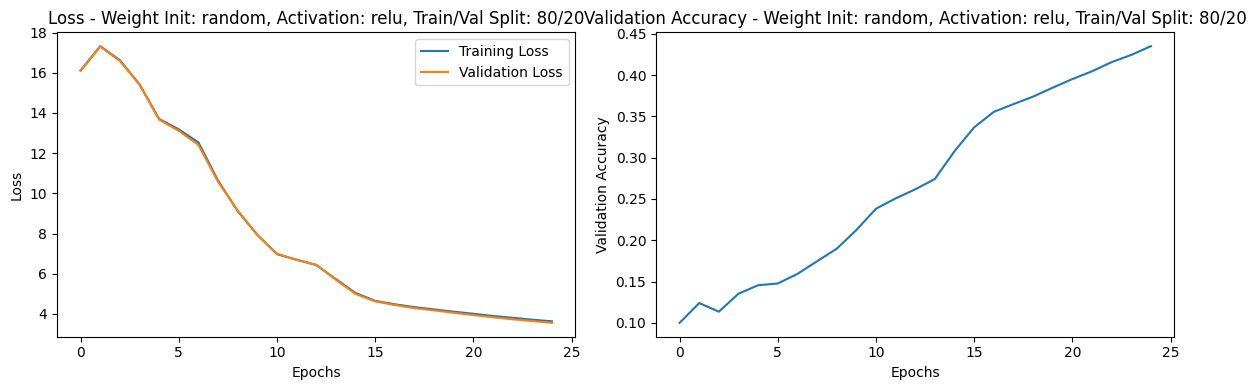

Training with Gradient Method: gradient_descent, Weight Init: random, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 17.0406, Val Loss: 17.0484, Val Accuracy: 0.0749
Epoch 2/25 - Train Loss: 15.5341, Val Loss: 15.4943, Val Accuracy: 0.0850
Epoch 3/25 - Train Loss: 13.6827, Val Loss: 13.7103, Val Accuracy: 0.0933
Epoch 4/25 - Train Loss: 12.0845, Val Loss: 12.1186, Val Accuracy: 0.0991
Epoch 5/25 - Train Loss: 11.0892, Val Loss: 11.1058, Val Accuracy: 0.1047
Epoch 6/25 - Train Loss: 10.6833, Val Loss: 10.7192, Val Accuracy: 0.1057
Epoch 7/25 - Train Loss: 10.5099, Val Loss: 10.5413, Val Accuracy: 0.1072
Epoch 8/25 - Train Loss: 10.1761, Val Loss: 10.2352, Val Accuracy: 0.1071
Epoch 9/25 - Train Loss: 9.5505, Val Loss: 9.5856, Val Accuracy: 0.1068
Epoch 10/25 - Train Loss: 9.1465, Val Loss: 9.1883, Val Accuracy: 0.1077
Epoch 11/25 - Train Loss: 8.9234, Val Loss: 8.9595, Val Accuracy: 0.1072
Epoch 12/25 - Train Loss: 8.7341, Val Loss: 8.7671, Val Accuracy: 0.1067
Epoch

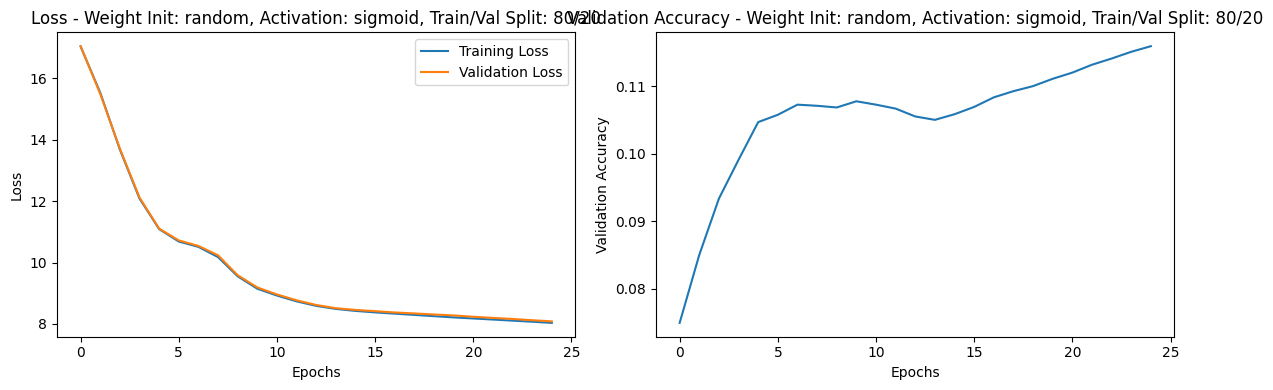

Training with Gradient Method: gradient_descent, Weight Init: random, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 13.8515, Val Loss: 13.8162, Val Accuracy: 0.0587
Epoch 2/25 - Train Loss: 16.7287, Val Loss: 16.6623, Val Accuracy: 0.1203
Epoch 3/25 - Train Loss: 16.1357, Val Loss: 16.1555, Val Accuracy: 0.1010
Early stopping...


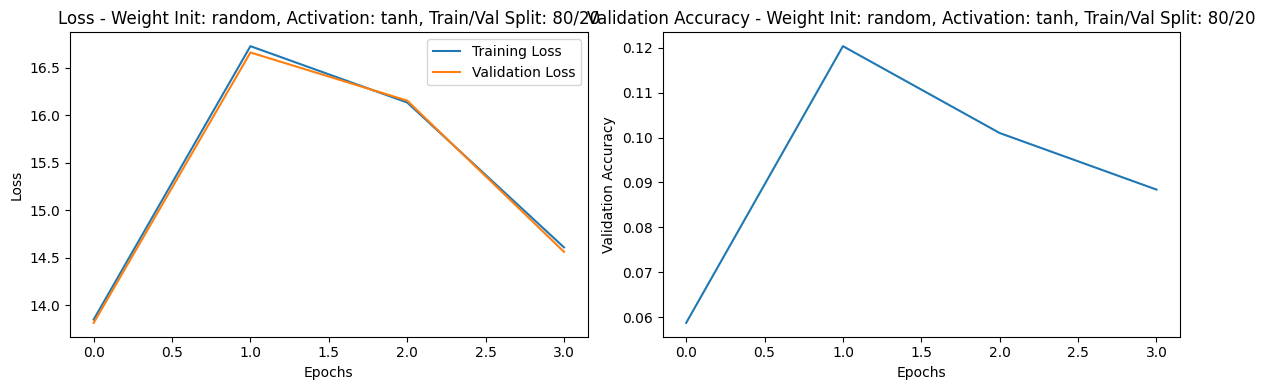

Training with Gradient Method: gradient_descent, Weight Init: large, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 13.2785, Val Loss: 13.2865, Val Accuracy: 0.0903
Epoch 2/25 - Train Loss: 17.7829, Val Loss: 17.8033, Val Accuracy: 0.1012
Epoch 3/25 - Train Loss: 16.6673, Val Loss: 16.7026, Val Accuracy: 0.1071
Early stopping...


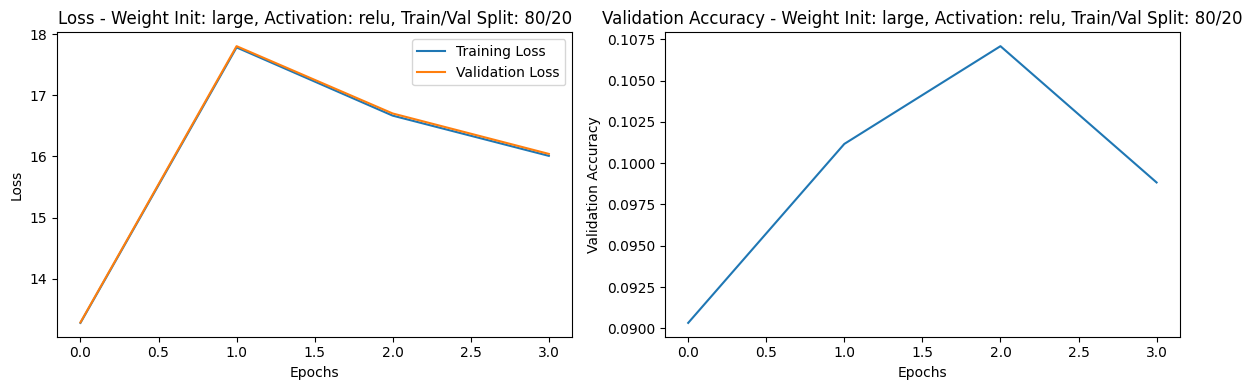

Training with Gradient Method: gradient_descent, Weight Init: large, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 14.3181, Val Loss: 14.2682, Val Accuracy: 0.1377
Epoch 2/25 - Train Loss: 14.1653, Val Loss: 14.0919, Val Accuracy: 0.1311
Epoch 3/25 - Train Loss: 13.0946, Val Loss: 13.1261, Val Accuracy: 0.1238
Epoch 4/25 - Train Loss: 11.8348, Val Loss: 11.8352, Val Accuracy: 0.1216
Epoch 5/25 - Train Loss: 10.7431, Val Loss: 10.7399, Val Accuracy: 0.1241
Epoch 6/25 - Train Loss: 9.9581, Val Loss: 9.9476, Val Accuracy: 0.1250
Epoch 7/25 - Train Loss: 9.4983, Val Loss: 9.4962, Val Accuracy: 0.1262
Epoch 8/25 - Train Loss: 9.2414, Val Loss: 9.2598, Val Accuracy: 0.1263
Epoch 9/25 - Train Loss: 9.1031, Val Loss: 9.1168, Val Accuracy: 0.1256
Epoch 10/25 - Train Loss: 9.0170, Val Loss: 9.0353, Val Accuracy: 0.1258
Epoch 11/25 - Train Loss: 8.9606, Val Loss: 8.9835, Val Accuracy: 0.1263
Epoch 12/25 - Train Loss: 8.9092, Val Loss: 8.9362, Val Accuracy: 0.1279
Epoch 13/25 

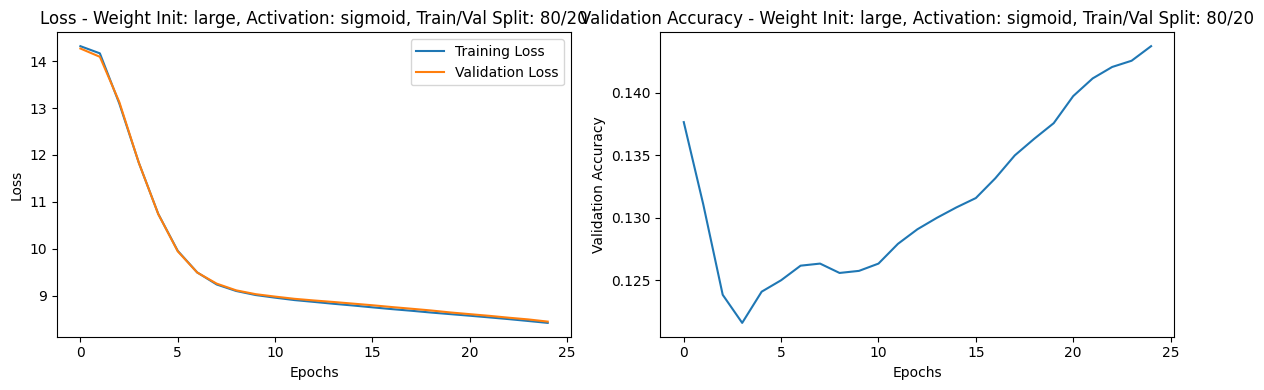

Training with Gradient Method: gradient_descent, Weight Init: large, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 17.3201, Val Loss: 17.3305, Val Accuracy: 0.0777
Epoch 2/25 - Train Loss: 15.9412, Val Loss: 15.9285, Val Accuracy: 0.0921
Epoch 3/25 - Train Loss: 15.0444, Val Loss: 15.0023, Val Accuracy: 0.1008
Epoch 4/25 - Train Loss: 14.2853, Val Loss: 14.2341, Val Accuracy: 0.0954
Epoch 5/25 - Train Loss: 12.4031, Val Loss: 12.3475, Val Accuracy: 0.0973
Epoch 6/25 - Train Loss: 10.8959, Val Loss: 10.7756, Val Accuracy: 0.1024
Epoch 7/25 - Train Loss: 10.5146, Val Loss: 10.4222, Val Accuracy: 0.1109
Epoch 8/25 - Train Loss: 10.3730, Val Loss: 10.2970, Val Accuracy: 0.1132
Epoch 9/25 - Train Loss: 10.2761, Val Loss: 10.2189, Val Accuracy: 0.1151
Epoch 10/25 - Train Loss: 10.1937, Val Loss: 10.1302, Val Accuracy: 0.1163
Epoch 11/25 - Train Loss: 10.1156, Val Loss: 10.0263, Val Accuracy: 0.1182
Epoch 12/25 - Train Loss: 9.9989, Val Loss: 9.9289, Val Accuracy: 0.1204
Epo

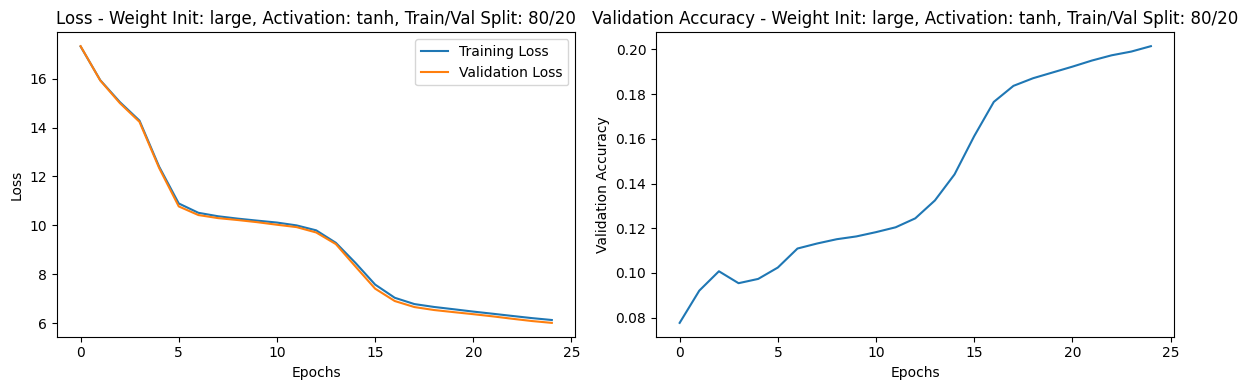

Training with Gradient Method: gradient_descent, Weight Init: xavier, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 15.1319, Val Loss: 15.1303, Val Accuracy: 0.1092
Epoch 2/25 - Train Loss: 17.8515, Val Loss: 17.8467, Val Accuracy: 0.1039
Epoch 3/25 - Train Loss: 17.3309, Val Loss: 17.3548, Val Accuracy: 0.1098
Early stopping...


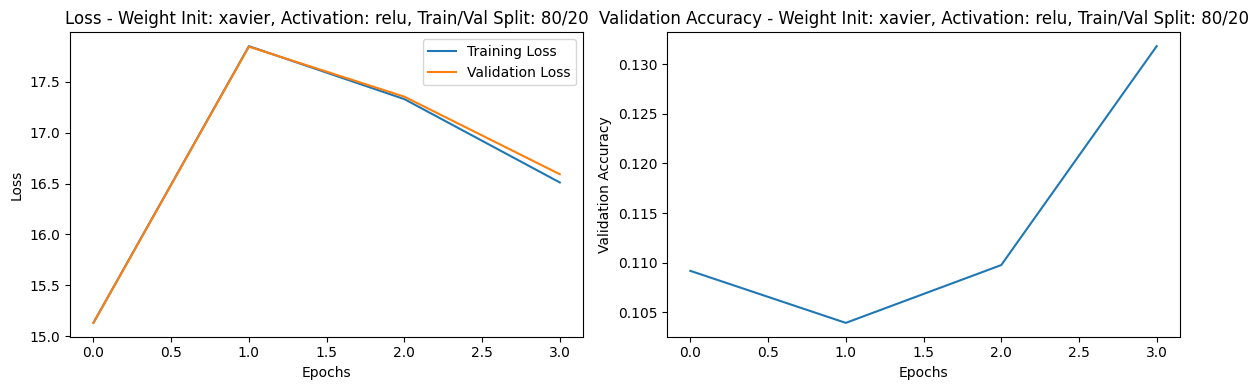

Training with Gradient Method: gradient_descent, Weight Init: xavier, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 15.5830, Val Loss: 15.6019, Val Accuracy: 0.0927
Epoch 2/25 - Train Loss: 14.1295, Val Loss: 14.0935, Val Accuracy: 0.0948
Epoch 3/25 - Train Loss: 12.4727, Val Loss: 12.4296, Val Accuracy: 0.0967
Epoch 4/25 - Train Loss: 11.0185, Val Loss: 10.9936, Val Accuracy: 0.0945
Epoch 5/25 - Train Loss: 10.0421, Val Loss: 9.9864, Val Accuracy: 0.0946
Epoch 6/25 - Train Loss: 9.4505, Val Loss: 9.4178, Val Accuracy: 0.0946
Epoch 7/25 - Train Loss: 9.0067, Val Loss: 8.9995, Val Accuracy: 0.0948
Epoch 8/25 - Train Loss: 8.6927, Val Loss: 8.6723, Val Accuracy: 0.0955
Epoch 9/25 - Train Loss: 8.5211, Val Loss: 8.5051, Val Accuracy: 0.0972
Epoch 10/25 - Train Loss: 8.4277, Val Loss: 8.4131, Val Accuracy: 0.0992
Epoch 11/25 - Train Loss: 8.3688, Val Loss: 8.3641, Val Accuracy: 0.0993
Epoch 12/25 - Train Loss: 8.3229, Val Loss: 8.3126, Val Accuracy: 0.1003
Epoch 13/25 

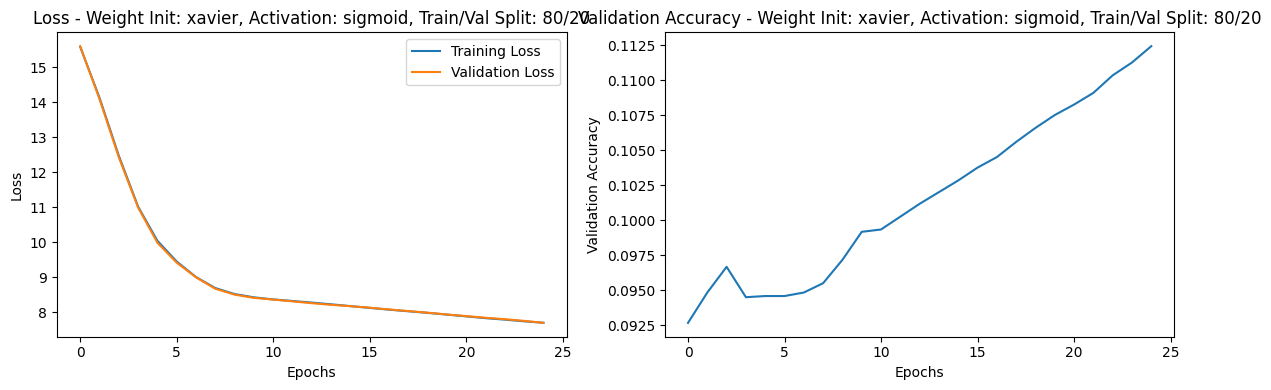

Training with Gradient Method: gradient_descent, Weight Init: xavier, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 16.0003, Val Loss: 15.9612, Val Accuracy: 0.1184
Epoch 2/25 - Train Loss: 16.1850, Val Loss: 16.1804, Val Accuracy: 0.0995
Epoch 3/25 - Train Loss: 15.4562, Val Loss: 15.4547, Val Accuracy: 0.0723
Epoch 4/25 - Train Loss: 13.8322, Val Loss: 13.8636, Val Accuracy: 0.0548
Epoch 5/25 - Train Loss: 12.5219, Val Loss: 12.5908, Val Accuracy: 0.0541
Epoch 6/25 - Train Loss: 11.7880, Val Loss: 11.8402, Val Accuracy: 0.0581
Epoch 7/25 - Train Loss: 11.0048, Val Loss: 11.0166, Val Accuracy: 0.0634
Epoch 8/25 - Train Loss: 10.0932, Val Loss: 10.0646, Val Accuracy: 0.0689
Epoch 9/25 - Train Loss: 9.4055, Val Loss: 9.3828, Val Accuracy: 0.0762
Epoch 10/25 - Train Loss: 9.0909, Val Loss: 9.0520, Val Accuracy: 0.0834
Epoch 11/25 - Train Loss: 8.9407, Val Loss: 8.8961, Val Accuracy: 0.0875
Epoch 12/25 - Train Loss: 8.8345, Val Loss: 8.7960, Val Accuracy: 0.0895
Epoch 13

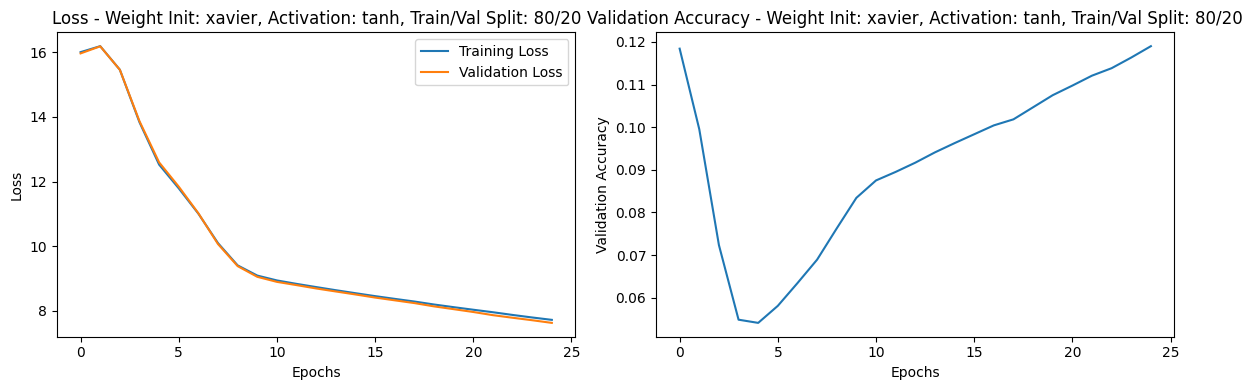

Training with Gradient Method: gradient_descent, Weight Init: he, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 16.5961, Val Loss: 16.6181, Val Accuracy: 0.0678
Epoch 2/25 - Train Loss: 16.2336, Val Loss: 16.2528, Val Accuracy: 0.0798
Epoch 3/25 - Train Loss: 14.3967, Val Loss: 14.4068, Val Accuracy: 0.0912
Epoch 4/25 - Train Loss: 12.9625, Val Loss: 12.9709, Val Accuracy: 0.1152
Epoch 5/25 - Train Loss: 12.0772, Val Loss: 12.0647, Val Accuracy: 0.1277
Epoch 6/25 - Train Loss: 11.7409, Val Loss: 11.7131, Val Accuracy: 0.1336
Epoch 7/25 - Train Loss: 10.9598, Val Loss: 10.9114, Val Accuracy: 0.1319
Epoch 8/25 - Train Loss: 9.9483, Val Loss: 9.8441, Val Accuracy: 0.1366
Epoch 9/25 - Train Loss: 9.1046, Val Loss: 9.0202, Val Accuracy: 0.1664
Epoch 10/25 - Train Loss: 8.8015, Val Loss: 8.7168, Val Accuracy: 0.1816
Epoch 11/25 - Train Loss: 8.6335, Val Loss: 8.5742, Val Accuracy: 0.1905
Epoch 12/25 - Train Loss: 8.4320, Val Loss: 8.4031, Val Accuracy: 0.2003
Epoch 13/25 - 

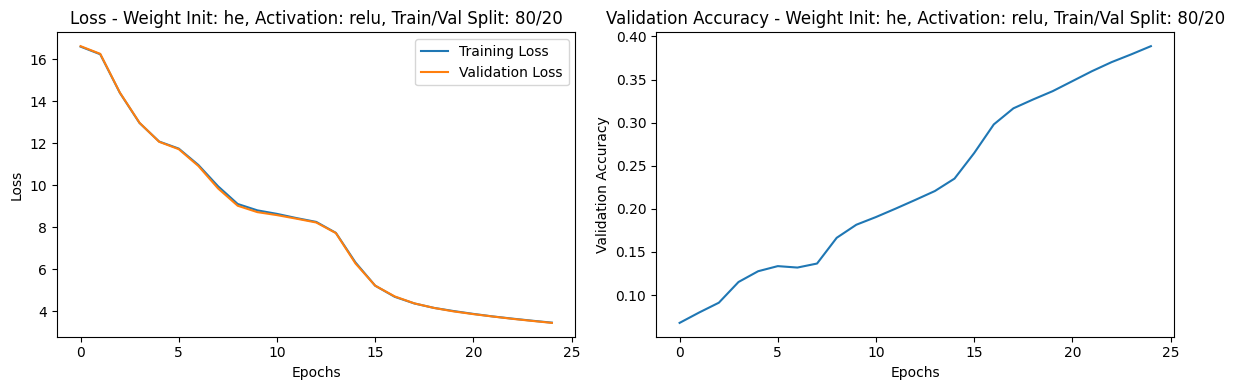

Training with Gradient Method: gradient_descent, Weight Init: he, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 14.4603, Val Loss: 14.5581, Val Accuracy: 0.1462
Epoch 2/25 - Train Loss: 13.7009, Val Loss: 13.7483, Val Accuracy: 0.1484
Epoch 3/25 - Train Loss: 12.3679, Val Loss: 12.4000, Val Accuracy: 0.1552
Epoch 4/25 - Train Loss: 11.0277, Val Loss: 11.0745, Val Accuracy: 0.1861
Epoch 5/25 - Train Loss: 9.8119, Val Loss: 9.8873, Val Accuracy: 0.2125
Epoch 6/25 - Train Loss: 8.8981, Val Loss: 8.9005, Val Accuracy: 0.2193
Epoch 7/25 - Train Loss: 8.3985, Val Loss: 8.4102, Val Accuracy: 0.2213
Epoch 8/25 - Train Loss: 8.1938, Val Loss: 8.2155, Val Accuracy: 0.2204
Epoch 9/25 - Train Loss: 7.9907, Val Loss: 8.0346, Val Accuracy: 0.2219
Epoch 10/25 - Train Loss: 7.6870, Val Loss: 7.7485, Val Accuracy: 0.2246
Epoch 11/25 - Train Loss: 7.2548, Val Loss: 7.3271, Val Accuracy: 0.2271
Epoch 12/25 - Train Loss: 6.9294, Val Loss: 6.9795, Val Accuracy: 0.2302
Epoch 13/25 - Tra

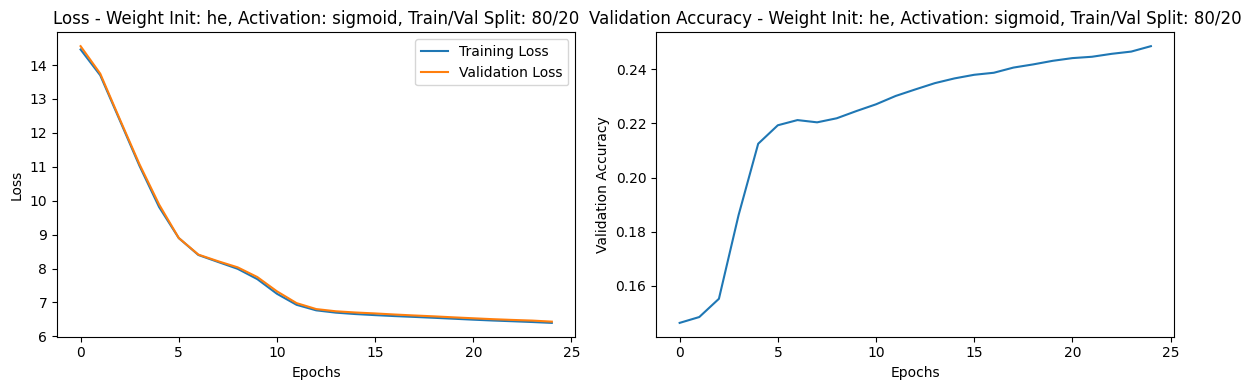

Training with Gradient Method: gradient_descent, Weight Init: he, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 16.7668, Val Loss: 16.8375, Val Accuracy: 0.0972
Epoch 2/25 - Train Loss: 17.6647, Val Loss: 17.7018, Val Accuracy: 0.0912
Epoch 3/25 - Train Loss: 17.3182, Val Loss: 17.3671, Val Accuracy: 0.0917
Early stopping...


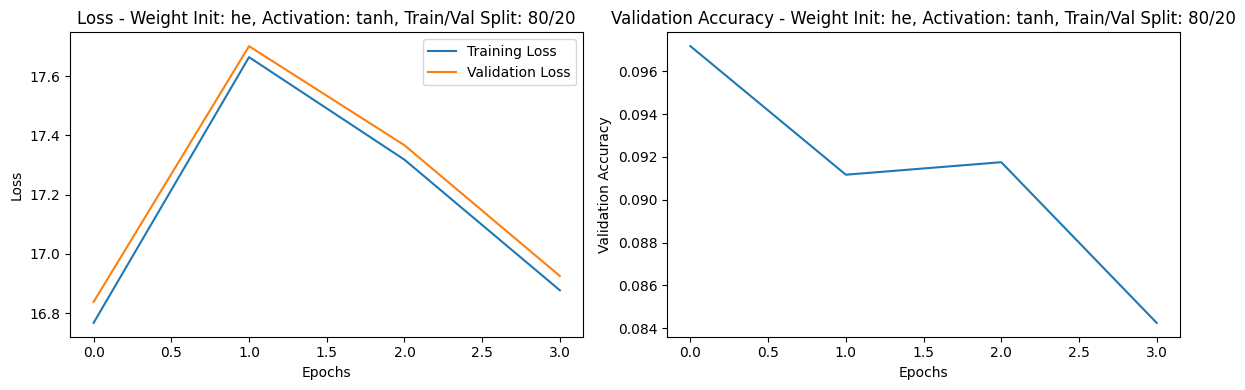

Training with Gradient Method: stochastic_gradient_descent, Weight Init: random, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.2145, Val Loss: 0.2321, Val Accuracy: 0.9490
Epoch 2/25 - Train Loss: 0.2014, Val Loss: 0.2686, Val Accuracy: 0.9636
Epoch 3/25 - Train Loss: 0.1512, Val Loss: 0.2140, Val Accuracy: 0.9683
Epoch 4/25 - Train Loss: 0.1056, Val Loss: 0.1860, Val Accuracy: 0.9728
Epoch 5/25 - Train Loss: 0.0527, Val Loss: 0.1367, Val Accuracy: 0.9745
Epoch 6/25 - Train Loss: 0.0813, Val Loss: 0.1897, Val Accuracy: 0.9762
Epoch 7/25 - Train Loss: 0.0811, Val Loss: 0.2127, Val Accuracy: 0.9762
Early stopping...


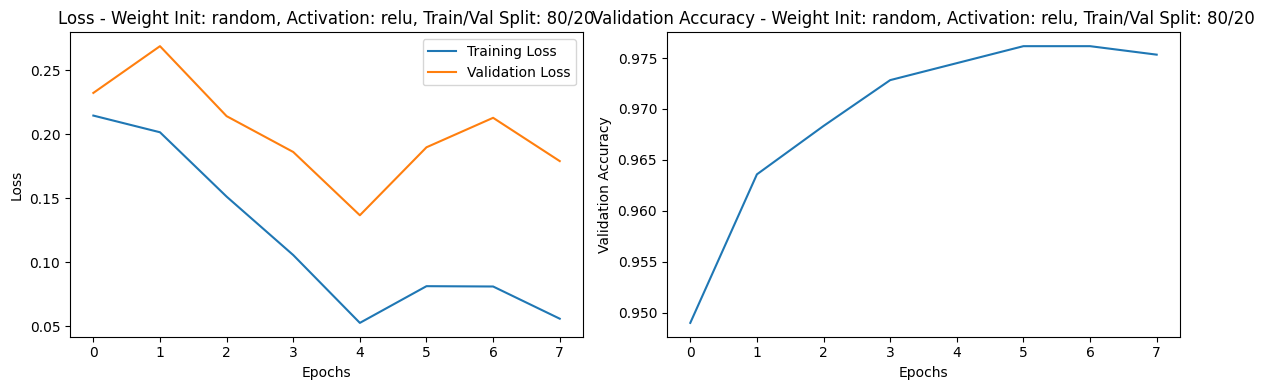

Training with Gradient Method: stochastic_gradient_descent, Weight Init: random, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.5598, Val Loss: 0.5376, Val Accuracy: 0.8956
Epoch 2/25 - Train Loss: 0.6819, Val Loss: 0.6982, Val Accuracy: 0.9107
Epoch 3/25 - Train Loss: 0.6445, Val Loss: 0.6822, Val Accuracy: 0.9117
Early stopping...


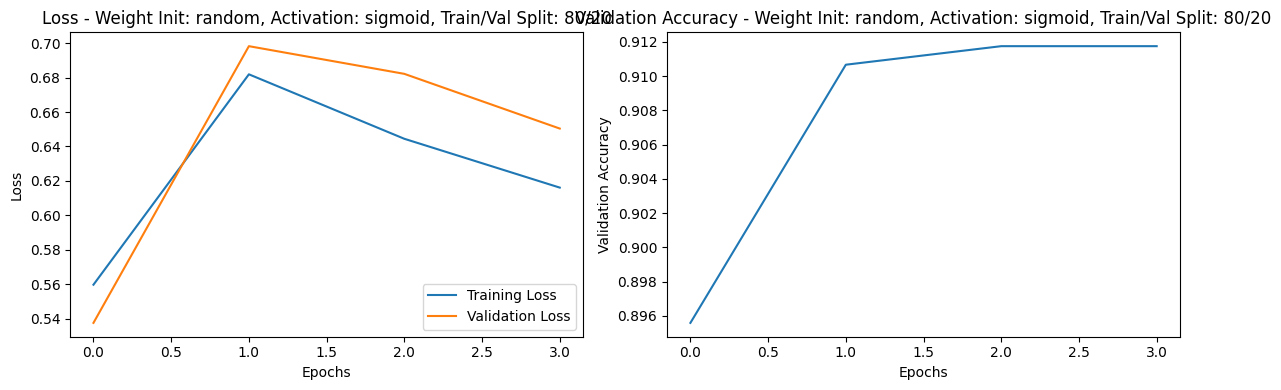

Training with Gradient Method: stochastic_gradient_descent, Weight Init: random, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 2.0178, Val Loss: 1.9592, Val Accuracy: 0.7687


<ipython-input-10-afdb33bc2eb0>:21: RuntimeWarning: invalid value encountered in multiply
  dZ = dA * derivative_of_tanh(activations[l + 1])
<ipython-input-10-afdb33bc2eb0>:10: RuntimeWarning: invalid value encountered in multiply
  dW[L - 1] = (np.dot(dZ, activations[-2].T) / m) + lambda_reg * weights[L - 1]
<ipython-input-10-afdb33bc2eb0>:25: RuntimeWarning: invalid value encountered in multiply
  dW[l] = (np.dot(dZ, activations[l].T) / m) + lambda_reg * weights[l]


Epoch 2/25 - Train Loss: nan, Val Loss: nan, Val Accuracy: 0.0999
Epoch 3/25 - Train Loss: nan, Val Loss: nan, Val Accuracy: 0.0999
Early stopping...


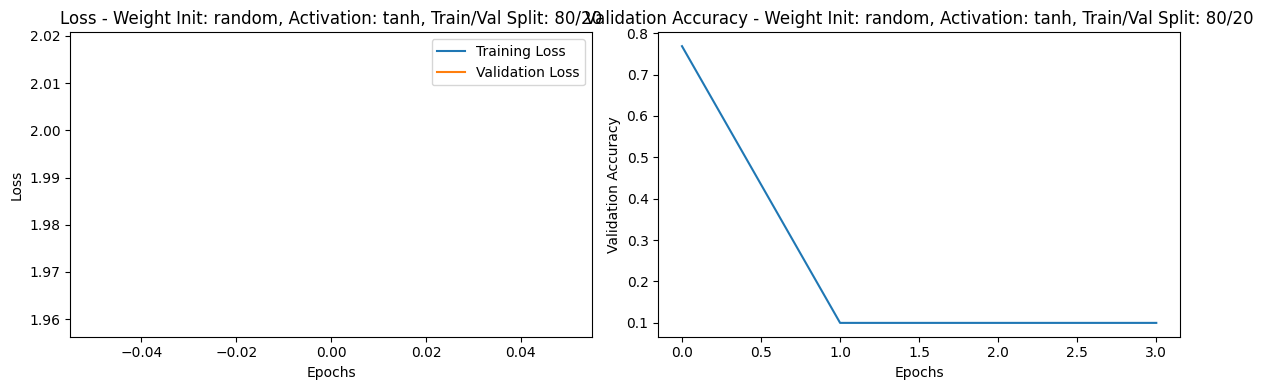

Training with Gradient Method: stochastic_gradient_descent, Weight Init: large, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.2841, Val Loss: 0.2961, Val Accuracy: 0.9547
Epoch 2/25 - Train Loss: 0.1411, Val Loss: 0.1822, Val Accuracy: 0.9623
Epoch 3/25 - Train Loss: 0.1523, Val Loss: 0.2341, Val Accuracy: 0.9688
Epoch 4/25 - Train Loss: 0.0811, Val Loss: 0.1502, Val Accuracy: 0.9732
Epoch 5/25 - Train Loss: 0.0775, Val Loss: 0.1684, Val Accuracy: 0.9752
Epoch 6/25 - Train Loss: 0.0533, Val Loss: 0.1712, Val Accuracy: 0.9742
Epoch 7/25 - Train Loss: 0.0382, Val Loss: 0.1262, Val Accuracy: 0.9754
Epoch 8/25 - Train Loss: 0.0422, Val Loss: 0.1726, Val Accuracy: 0.9764
Epoch 9/25 - Train Loss: 0.0447, Val Loss: 0.1973, Val Accuracy: 0.9761
Early stopping...


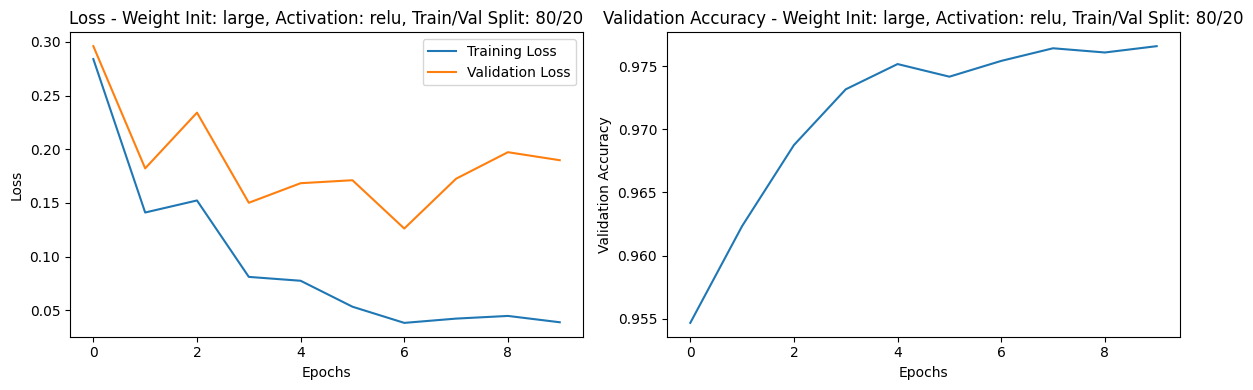

Training with Gradient Method: stochastic_gradient_descent, Weight Init: large, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.6425, Val Loss: 0.6734, Val Accuracy: 0.8940
Epoch 2/25 - Train Loss: 0.8144, Val Loss: 0.8244, Val Accuracy: 0.9115
Epoch 3/25 - Train Loss: 0.9017, Val Loss: 0.9383, Val Accuracy: 0.8991
Epoch 4/25 - Train Loss: 0.5880, Val Loss: 0.6101, Val Accuracy: 0.9070
Epoch 5/25 - Train Loss: 0.6874, Val Loss: 0.7020, Val Accuracy: 0.9139
Epoch 6/25 - Train Loss: 0.6686, Val Loss: 0.6982, Val Accuracy: 0.9112
Early stopping...


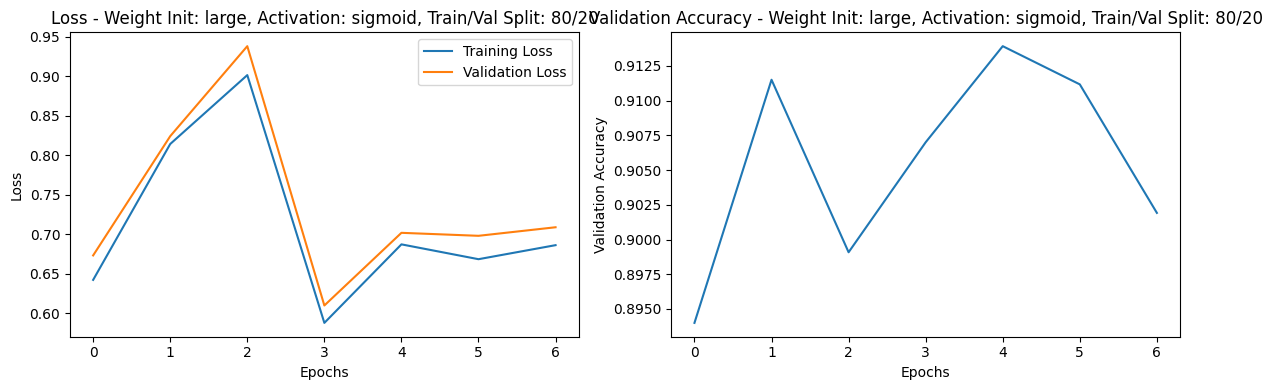

Training with Gradient Method: stochastic_gradient_descent, Weight Init: large, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 5.7377, Val Loss: 5.7234, Val Accuracy: 0.4162
Epoch 2/25 - Train Loss: nan, Val Loss: nan, Val Accuracy: 0.0999
Epoch 3/25 - Train Loss: nan, Val Loss: nan, Val Accuracy: 0.0999
Early stopping...


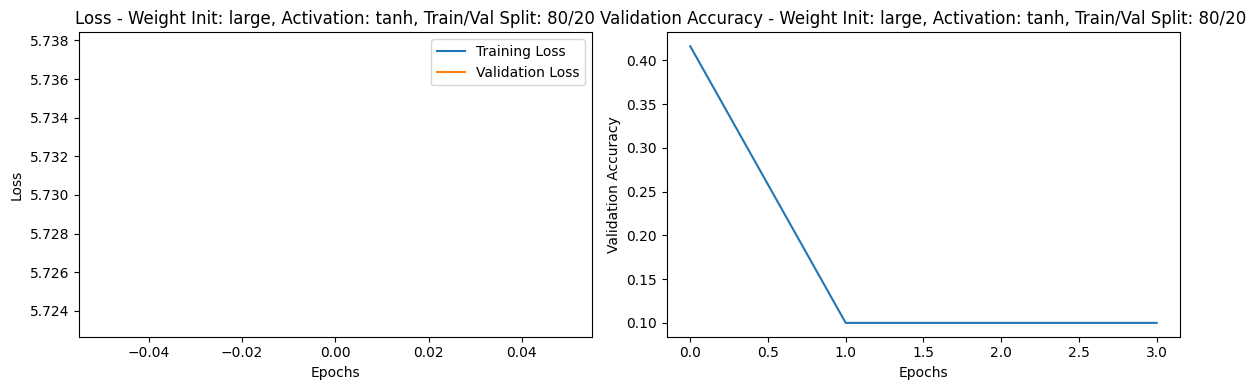

Training with Gradient Method: stochastic_gradient_descent, Weight Init: xavier, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.2955, Val Loss: 0.3243, Val Accuracy: 0.9542
Epoch 2/25 - Train Loss: 0.1881, Val Loss: 0.2411, Val Accuracy: 0.9632
Epoch 3/25 - Train Loss: 0.1171, Val Loss: 0.1832, Val Accuracy: 0.9662
Epoch 4/25 - Train Loss: 0.1301, Val Loss: 0.2149, Val Accuracy: 0.9702
Epoch 5/25 - Train Loss: 0.0748, Val Loss: 0.1805, Val Accuracy: 0.9740
Epoch 6/25 - Train Loss: 0.0701, Val Loss: 0.1668, Val Accuracy: 0.9772
Epoch 7/25 - Train Loss: 0.0482, Val Loss: 0.1619, Val Accuracy: 0.9750
Epoch 8/25 - Train Loss: 0.0586, Val Loss: 0.2004, Val Accuracy: 0.9766
Epoch 9/25 - Train Loss: 0.0408, Val Loss: 0.1777, Val Accuracy: 0.9777
Early stopping...


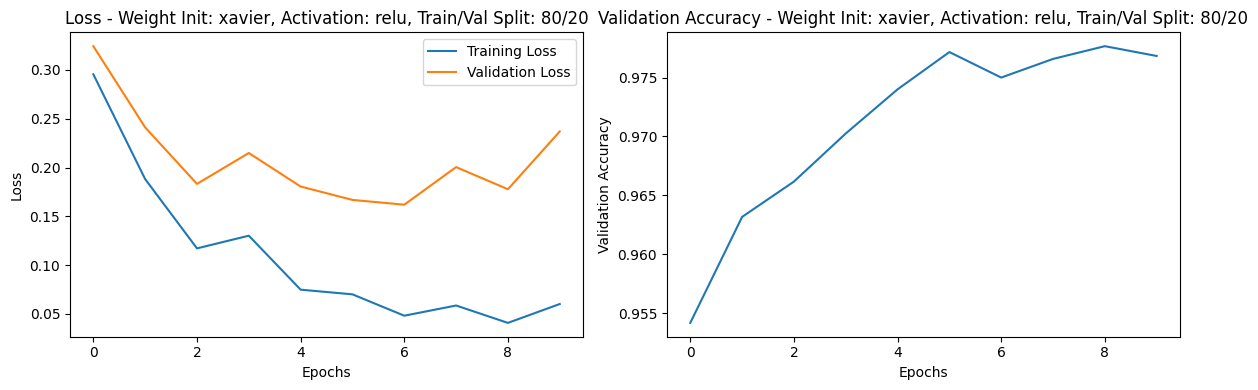

Training with Gradient Method: stochastic_gradient_descent, Weight Init: xavier, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.8740, Val Loss: 0.8756, Val Accuracy: 0.8962
Epoch 2/25 - Train Loss: 0.7113, Val Loss: 0.7050, Val Accuracy: 0.9118
Epoch 3/25 - Train Loss: 0.6976, Val Loss: 0.6951, Val Accuracy: 0.9150
Epoch 4/25 - Train Loss: 0.6241, Val Loss: 0.6278, Val Accuracy: 0.8985
Epoch 5/25 - Train Loss: 0.5669, Val Loss: 0.5765, Val Accuracy: 0.9126
Epoch 6/25 - Train Loss: 0.5940, Val Loss: 0.6111, Val Accuracy: 0.9082
Epoch 7/25 - Train Loss: 0.5396, Val Loss: 0.5731, Val Accuracy: 0.9058
Epoch 8/25 - Train Loss: 0.5628, Val Loss: 0.5673, Val Accuracy: 0.9125
Epoch 9/25 - Train Loss: 0.6380, Val Loss: 0.6725, Val Accuracy: 0.8998
Epoch 10/25 - Train Loss: 0.7760, Val Loss: 0.7673, Val Accuracy: 0.8813
Early stopping...


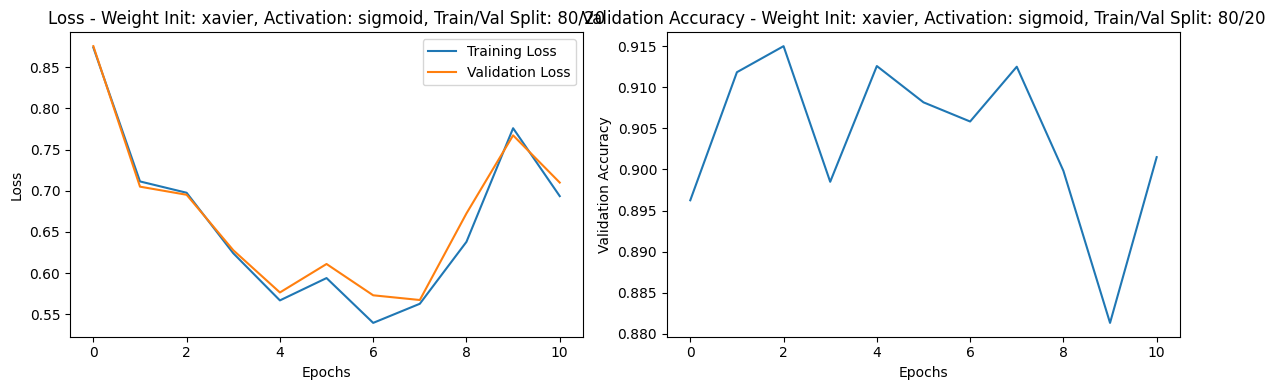

Training with Gradient Method: stochastic_gradient_descent, Weight Init: xavier, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: nan, Val Loss: nan, Val Accuracy: 0.0999
Epoch 2/25 - Train Loss: nan, Val Loss: nan, Val Accuracy: 0.0999
Early stopping...


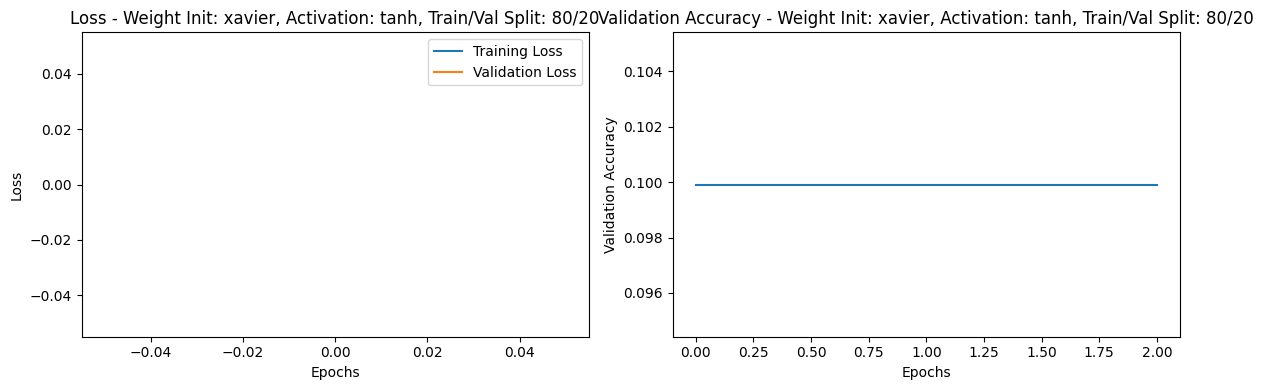

Training with Gradient Method: stochastic_gradient_descent, Weight Init: he, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.3172, Val Loss: 0.3437, Val Accuracy: 0.9526
Epoch 2/25 - Train Loss: 0.2003, Val Loss: 0.2446, Val Accuracy: 0.9663
Epoch 3/25 - Train Loss: 0.1552, Val Loss: 0.2405, Val Accuracy: 0.9678
Epoch 4/25 - Train Loss: 0.1202, Val Loss: 0.2250, Val Accuracy: 0.9722
Epoch 5/25 - Train Loss: 0.1008, Val Loss: 0.2051, Val Accuracy: 0.9741
Epoch 6/25 - Train Loss: 0.0602, Val Loss: 0.1801, Val Accuracy: 0.9752
Epoch 7/25 - Train Loss: 0.0456, Val Loss: 0.1637, Val Accuracy: 0.9764
Epoch 8/25 - Train Loss: 0.0377, Val Loss: 0.1563, Val Accuracy: 0.9772
Epoch 9/25 - Train Loss: 0.0356, Val Loss: 0.1865, Val Accuracy: 0.9782
Epoch 10/25 - Train Loss: 0.0271, Val Loss: 0.1572, Val Accuracy: 0.9782
Early stopping...


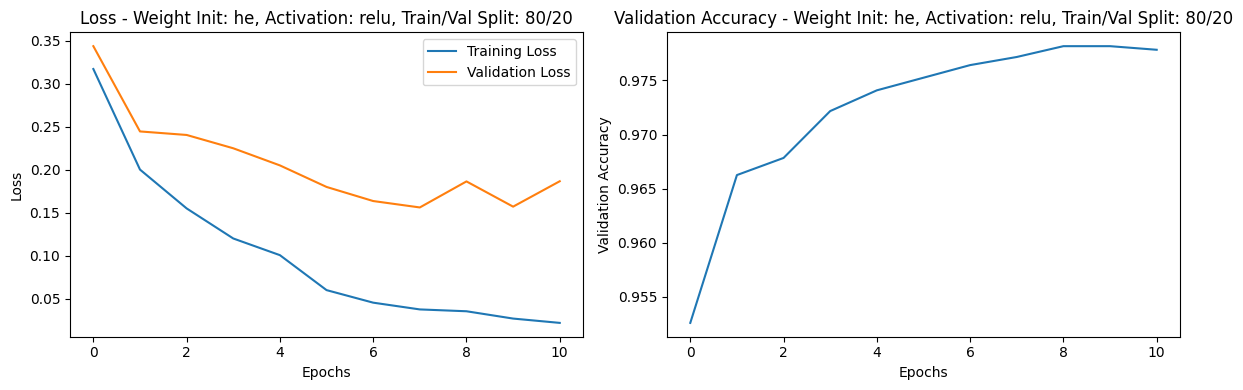

Training with Gradient Method: stochastic_gradient_descent, Weight Init: he, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.8798, Val Loss: 0.9047, Val Accuracy: 0.9001
Epoch 2/25 - Train Loss: 0.7031, Val Loss: 0.6821, Val Accuracy: 0.9151
Epoch 3/25 - Train Loss: 0.6622, Val Loss: 0.6615, Val Accuracy: 0.9138
Epoch 4/25 - Train Loss: 0.7259, Val Loss: 0.7477, Val Accuracy: 0.9092
Epoch 5/25 - Train Loss: 0.6511, Val Loss: 0.6868, Val Accuracy: 0.9058
Early stopping...


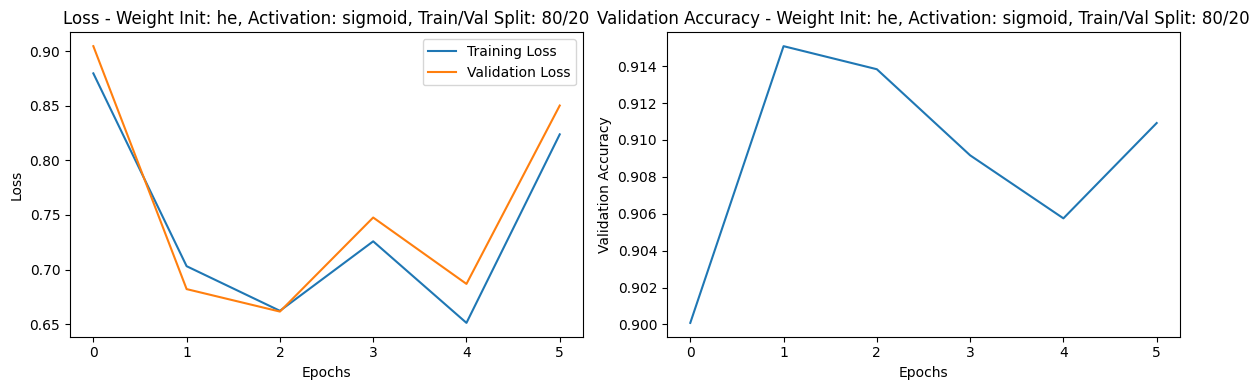

Training with Gradient Method: stochastic_gradient_descent, Weight Init: he, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.9365, Val Loss: 1.8815, Val Accuracy: 0.7734
Epoch 2/25 - Train Loss: nan, Val Loss: nan, Val Accuracy: 0.0999
Epoch 3/25 - Train Loss: nan, Val Loss: nan, Val Accuracy: 0.0999
Early stopping...


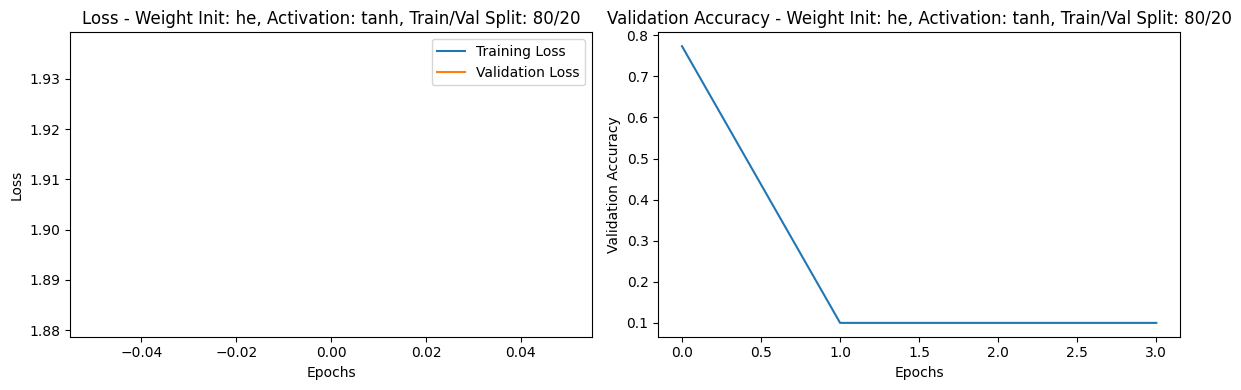

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: random, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.7681, Val Loss: 0.7792, Val Accuracy: 0.8946
Epoch 2/25 - Train Loss: 0.6635, Val Loss: 0.6664, Val Accuracy: 0.9144
Epoch 3/25 - Train Loss: 0.6213, Val Loss: 0.6255, Val Accuracy: 0.9231
Epoch 4/25 - Train Loss: 0.5370, Val Loss: 0.5392, Val Accuracy: 0.9303
Epoch 5/25 - Train Loss: 0.4410, Val Loss: 0.4550, Val Accuracy: 0.9383
Epoch 6/25 - Train Loss: 0.4351, Val Loss: 0.4579, Val Accuracy: 0.9433
Epoch 7/25 - Train Loss: 0.3950, Val Loss: 0.4186, Val Accuracy: 0.9457
Epoch 8/25 - Train Loss: 0.3837, Val Loss: 0.4187, Val Accuracy: 0.9483
Epoch 9/25 - Train Loss: 0.3544, Val Loss: 0.3840, Val Accuracy: 0.9503
Epoch 10/25 - Train Loss: 0.3163, Val Loss: 0.3518, Val Accuracy: 0.9532
Epoch 11/25 - Train Loss: 0.3000, Val Loss: 0.3336, Val Accuracy: 0.9557
Epoch 12/25 - Train Loss: 0.2978, Val Loss: 0.3492, Val Accuracy: 0.9567
Epoch 13/25 -

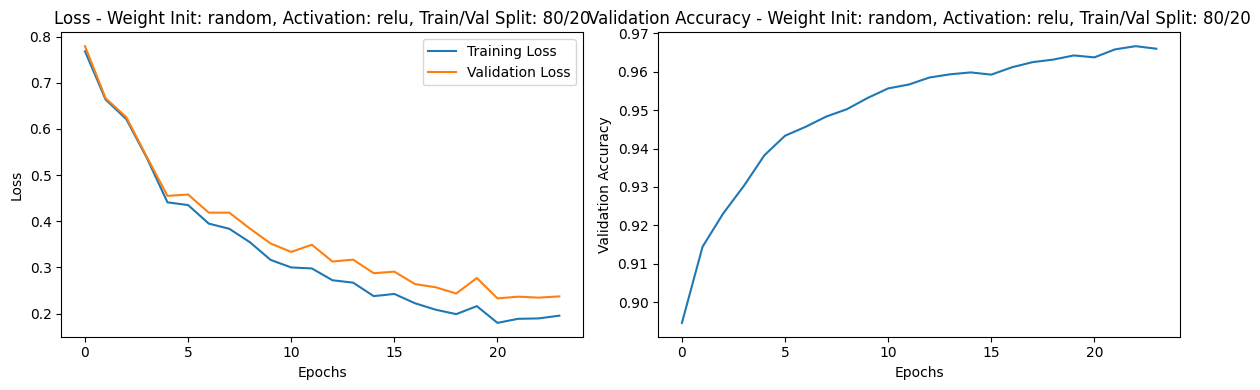

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: random, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.3686, Val Loss: 1.3122, Val Accuracy: 0.7814
Epoch 2/25 - Train Loss: 1.2305, Val Loss: 1.2241, Val Accuracy: 0.8459
Epoch 3/25 - Train Loss: 1.0942, Val Loss: 1.0749, Val Accuracy: 0.8536
Epoch 4/25 - Train Loss: 0.9844, Val Loss: 0.9699, Val Accuracy: 0.8705
Epoch 5/25 - Train Loss: 0.9707, Val Loss: 0.9509, Val Accuracy: 0.8757
Epoch 6/25 - Train Loss: 0.9544, Val Loss: 0.9387, Val Accuracy: 0.8806
Epoch 7/25 - Train Loss: 0.8351, Val Loss: 0.8340, Val Accuracy: 0.8838
Epoch 8/25 - Train Loss: 0.8478, Val Loss: 0.8470, Val Accuracy: 0.8854
Epoch 9/25 - Train Loss: 0.8748, Val Loss: 0.8718, Val Accuracy: 0.8942
Early stopping...


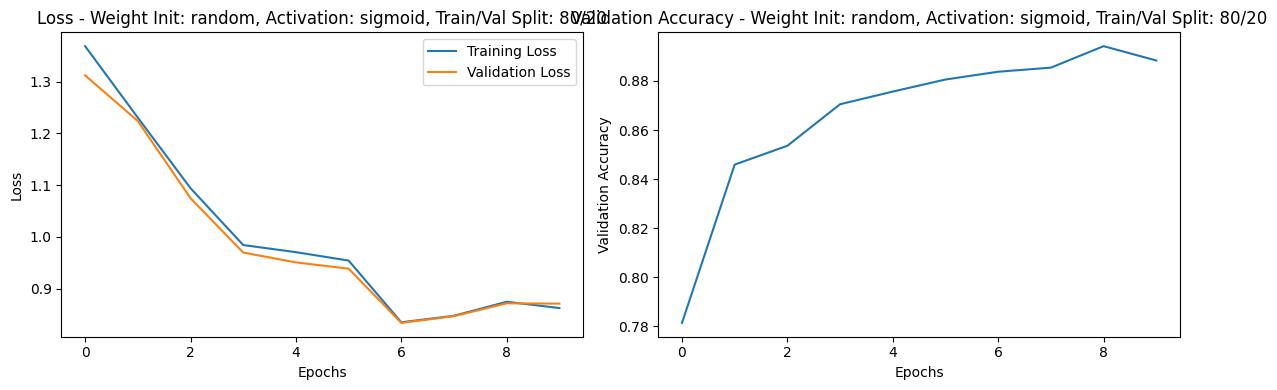

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: random, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.1049, Val Loss: 1.1283, Val Accuracy: 0.8529
Epoch 2/25 - Train Loss: 1.0539, Val Loss: 1.0499, Val Accuracy: 0.8768
Epoch 3/25 - Train Loss: 0.9340, Val Loss: 0.9427, Val Accuracy: 0.8765
Epoch 4/25 - Train Loss: 0.9570, Val Loss: 0.9557, Val Accuracy: 0.8688
Epoch 5/25 - Train Loss: 1.0447, Val Loss: 1.0318, Val Accuracy: 0.8668
Early stopping...


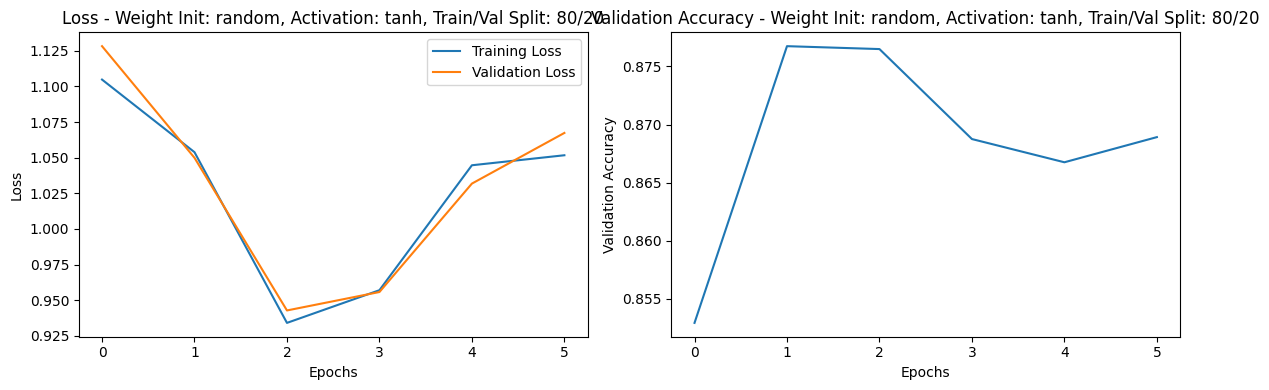

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: large, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.7823, Val Loss: 0.7652, Val Accuracy: 0.8928
Epoch 2/25 - Train Loss: 0.6909, Val Loss: 0.6552, Val Accuracy: 0.9165
Epoch 3/25 - Train Loss: 0.5881, Val Loss: 0.5619, Val Accuracy: 0.9240
Epoch 4/25 - Train Loss: 0.5275, Val Loss: 0.5117, Val Accuracy: 0.9347
Epoch 5/25 - Train Loss: 0.4785, Val Loss: 0.4664, Val Accuracy: 0.9385
Epoch 6/25 - Train Loss: 0.4402, Val Loss: 0.4317, Val Accuracy: 0.9421
Epoch 7/25 - Train Loss: 0.4049, Val Loss: 0.3985, Val Accuracy: 0.9467
Epoch 8/25 - Train Loss: 0.3582, Val Loss: 0.3597, Val Accuracy: 0.9513
Epoch 9/25 - Train Loss: 0.3566, Val Loss: 0.3640, Val Accuracy: 0.9528
Epoch 10/25 - Train Loss: 0.3159, Val Loss: 0.3253, Val Accuracy: 0.9549
Epoch 11/25 - Train Loss: 0.3040, Val Loss: 0.3194, Val Accuracy: 0.9566
Epoch 12/25 - Train Loss: 0.3199, Val Loss: 0.3381, Val Accuracy: 0.9572
Epoch 13/25 - 

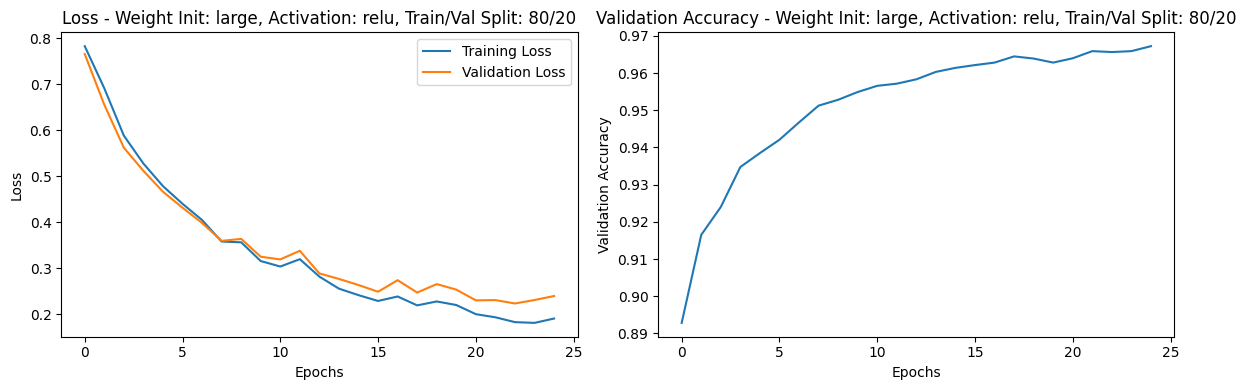

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: large, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.3068, Val Loss: 1.2746, Val Accuracy: 0.7963
Epoch 2/25 - Train Loss: 1.0823, Val Loss: 1.0683, Val Accuracy: 0.8349
Epoch 3/25 - Train Loss: 1.0560, Val Loss: 1.0438, Val Accuracy: 0.8520
Epoch 4/25 - Train Loss: 1.0584, Val Loss: 1.0351, Val Accuracy: 0.8608
Epoch 5/25 - Train Loss: 0.9804, Val Loss: 0.9766, Val Accuracy: 0.8685
Epoch 6/25 - Train Loss: 0.9834, Val Loss: 0.9821, Val Accuracy: 0.8770
Epoch 7/25 - Train Loss: 0.9286, Val Loss: 0.9130, Val Accuracy: 0.8749
Epoch 8/25 - Train Loss: 0.8339, Val Loss: 0.8397, Val Accuracy: 0.8847
Epoch 9/25 - Train Loss: 0.8975, Val Loss: 0.8904, Val Accuracy: 0.8879
Epoch 10/25 - Train Loss: 0.8434, Val Loss: 0.8388, Val Accuracy: 0.8873
Epoch 11/25 - Train Loss: 0.8712, Val Loss: 0.8614, Val Accuracy: 0.8893
Epoch 12/25 - Train Loss: 0.8300, Val Loss: 0.8356, Val Accuracy: 0.8896
Epoch 13/25

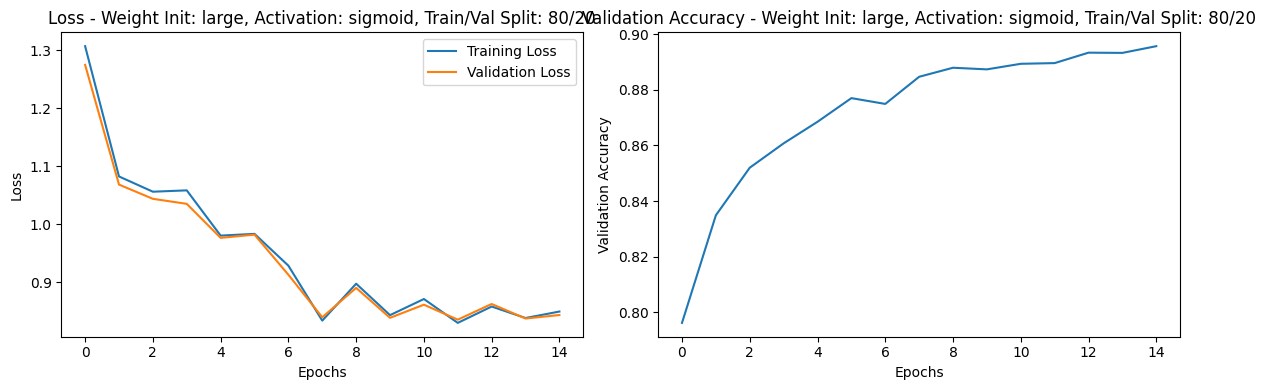

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: large, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.1858, Val Loss: 1.1420, Val Accuracy: 0.8498
Epoch 2/25 - Train Loss: 0.9784, Val Loss: 0.9771, Val Accuracy: 0.8785
Epoch 3/25 - Train Loss: 1.0411, Val Loss: 1.0688, Val Accuracy: 0.8817
Epoch 4/25 - Train Loss: 0.9692, Val Loss: 0.9681, Val Accuracy: 0.8735
Epoch 5/25 - Train Loss: 1.0475, Val Loss: 1.0704, Val Accuracy: 0.8668
Epoch 6/25 - Train Loss: 1.0485, Val Loss: 1.0641, Val Accuracy: 0.8476
Early stopping...


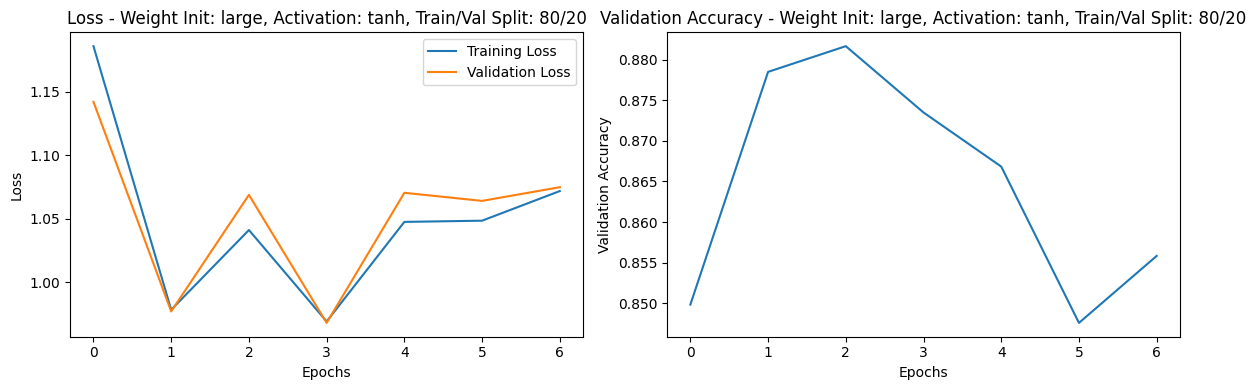

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: xavier, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.7776, Val Loss: 0.7620, Val Accuracy: 0.8915
Epoch 2/25 - Train Loss: 0.6127, Val Loss: 0.6216, Val Accuracy: 0.9130
Epoch 3/25 - Train Loss: 0.5511, Val Loss: 0.5667, Val Accuracy: 0.9255
Epoch 4/25 - Train Loss: 0.5152, Val Loss: 0.5357, Val Accuracy: 0.9315
Epoch 5/25 - Train Loss: 0.4423, Val Loss: 0.4765, Val Accuracy: 0.9374
Epoch 6/25 - Train Loss: 0.4198, Val Loss: 0.4463, Val Accuracy: 0.9430
Epoch 7/25 - Train Loss: 0.3832, Val Loss: 0.4170, Val Accuracy: 0.9454
Epoch 8/25 - Train Loss: 0.3548, Val Loss: 0.3865, Val Accuracy: 0.9493
Epoch 9/25 - Train Loss: 0.3138, Val Loss: 0.3528, Val Accuracy: 0.9520
Epoch 10/25 - Train Loss: 0.3146, Val Loss: 0.3465, Val Accuracy: 0.9539
Epoch 11/25 - Train Loss: 0.2724, Val Loss: 0.3178, Val Accuracy: 0.9547
Epoch 12/25 - Train Loss: 0.2620, Val Loss: 0.2968, Val Accuracy: 0.9573
Epoch 13/25 -

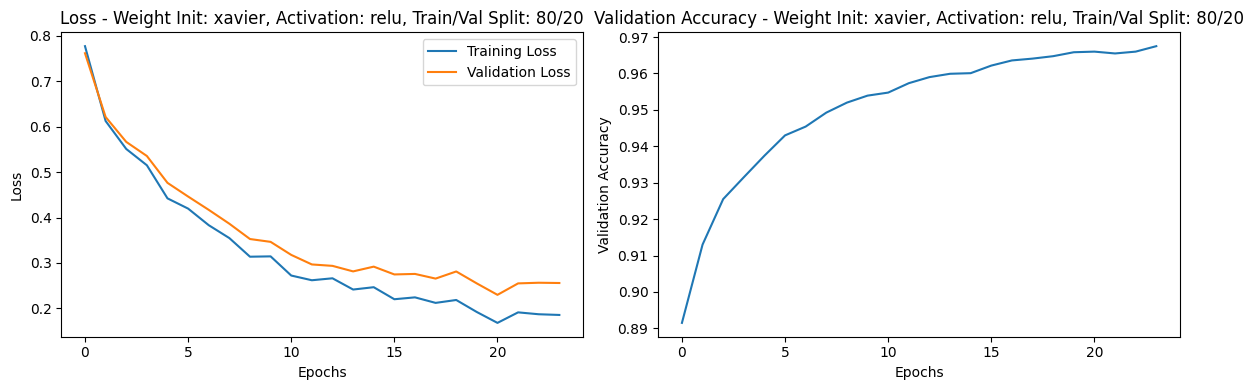

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: xavier, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.6192, Val Loss: 1.6047, Val Accuracy: 0.7645
Epoch 2/25 - Train Loss: 1.2422, Val Loss: 1.2139, Val Accuracy: 0.8327
Epoch 3/25 - Train Loss: 1.0297, Val Loss: 0.9750, Val Accuracy: 0.8560
Epoch 4/25 - Train Loss: 1.0060, Val Loss: 0.9669, Val Accuracy: 0.8660
Epoch 5/25 - Train Loss: 0.9471, Val Loss: 0.9250, Val Accuracy: 0.8723
Epoch 6/25 - Train Loss: 1.0856, Val Loss: 1.0334, Val Accuracy: 0.8755
Epoch 7/25 - Train Loss: 0.9750, Val Loss: 0.9504, Val Accuracy: 0.8818
Epoch 8/25 - Train Loss: 0.8864, Val Loss: 0.8492, Val Accuracy: 0.8900
Epoch 9/25 - Train Loss: 0.8120, Val Loss: 0.7876, Val Accuracy: 0.8877
Epoch 10/25 - Train Loss: 0.8601, Val Loss: 0.8279, Val Accuracy: 0.8917
Epoch 11/25 - Train Loss: 0.8611, Val Loss: 0.8379, Val Accuracy: 0.8952
Early stopping...


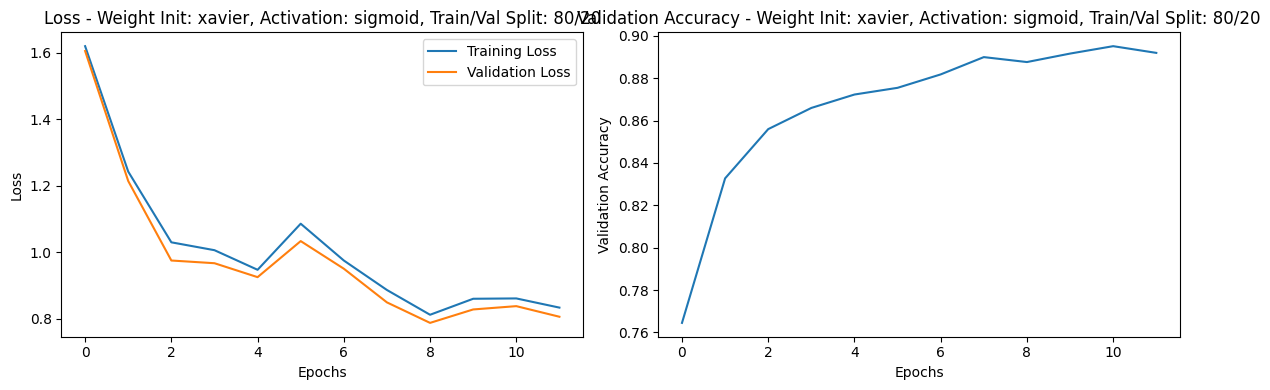

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: xavier, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.2243, Val Loss: 1.1541, Val Accuracy: 0.8500
Epoch 2/25 - Train Loss: 1.0051, Val Loss: 0.9798, Val Accuracy: 0.8775
Epoch 3/25 - Train Loss: 1.0342, Val Loss: 1.0410, Val Accuracy: 0.8728
Epoch 4/25 - Train Loss: 1.0301, Val Loss: 1.0286, Val Accuracy: 0.8723
Early stopping...


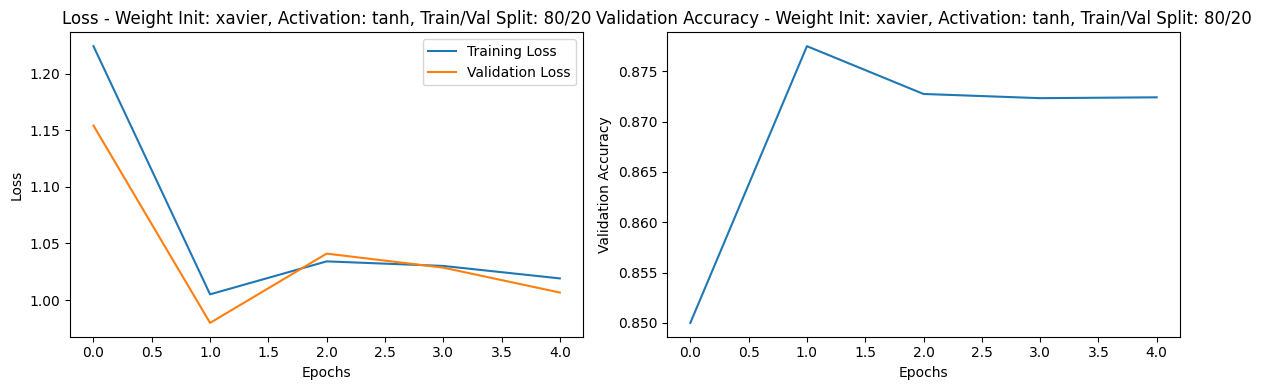

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: he, Activation: relu, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.8280, Val Loss: 0.7934, Val Accuracy: 0.8968
Epoch 2/25 - Train Loss: 0.6442, Val Loss: 0.6439, Val Accuracy: 0.9157
Epoch 3/25 - Train Loss: 0.5794, Val Loss: 0.5686, Val Accuracy: 0.9264
Epoch 4/25 - Train Loss: 0.4980, Val Loss: 0.4875, Val Accuracy: 0.9352
Epoch 5/25 - Train Loss: 0.4208, Val Loss: 0.4195, Val Accuracy: 0.9415
Epoch 6/25 - Train Loss: 0.3894, Val Loss: 0.3942, Val Accuracy: 0.9447
Epoch 7/25 - Train Loss: 0.3685, Val Loss: 0.3736, Val Accuracy: 0.9465
Epoch 8/25 - Train Loss: 0.3281, Val Loss: 0.3233, Val Accuracy: 0.9525
Epoch 9/25 - Train Loss: 0.3040, Val Loss: 0.3078, Val Accuracy: 0.9537
Epoch 10/25 - Train Loss: 0.2928, Val Loss: 0.2921, Val Accuracy: 0.9550
Epoch 11/25 - Train Loss: 0.2669, Val Loss: 0.2719, Val Accuracy: 0.9547
Epoch 12/25 - Train Loss: 0.2497, Val Loss: 0.2523, Val Accuracy: 0.9595
Epoch 13/25 - Tra

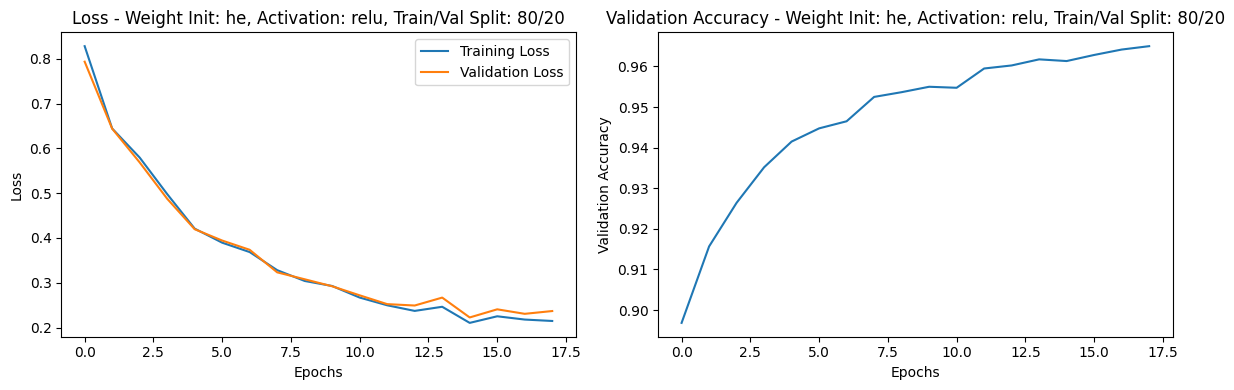

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: he, Activation: sigmoid, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.3244, Val Loss: 1.2953, Val Accuracy: 0.7798
Epoch 2/25 - Train Loss: 1.1146, Val Loss: 1.0778, Val Accuracy: 0.8462
Epoch 3/25 - Train Loss: 1.1226, Val Loss: 1.0822, Val Accuracy: 0.8518
Epoch 4/25 - Train Loss: 0.9598, Val Loss: 0.9485, Val Accuracy: 0.8708
Epoch 5/25 - Train Loss: 0.9669, Val Loss: 0.9607, Val Accuracy: 0.8751
Epoch 6/25 - Train Loss: 0.9157, Val Loss: 0.9199, Val Accuracy: 0.8816
Epoch 7/25 - Train Loss: 0.9183, Val Loss: 0.9046, Val Accuracy: 0.8850
Epoch 8/25 - Train Loss: 0.8670, Val Loss: 0.8483, Val Accuracy: 0.8886
Epoch 9/25 - Train Loss: 0.9200, Val Loss: 0.8962, Val Accuracy: 0.8917
Epoch 10/25 - Train Loss: 0.8045, Val Loss: 0.7948, Val Accuracy: 0.8947
Epoch 11/25 - Train Loss: 0.7972, Val Loss: 0.7996, Val Accuracy: 0.8974
Epoch 12/25 - Train Loss: 0.7767, Val Loss: 0.7760, Val Accuracy: 0.8983
Epoch 13/25 - 

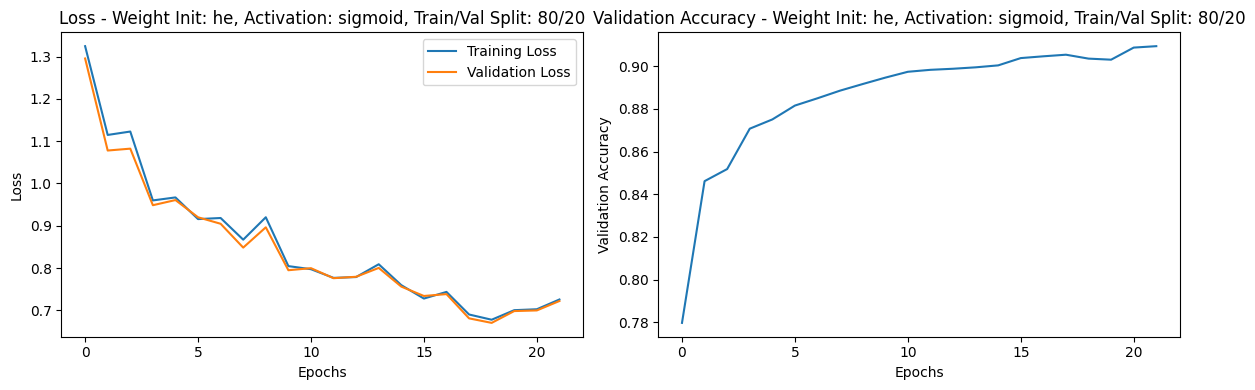

Training with Gradient Method: mini_batch_gradient_descent, Weight Init: he, Activation: tanh, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 1.2447, Val Loss: 1.2677, Val Accuracy: 0.8548
Epoch 2/25 - Train Loss: 0.9857, Val Loss: 1.0154, Val Accuracy: 0.8786
Epoch 3/25 - Train Loss: 0.9351, Val Loss: 0.9314, Val Accuracy: 0.8822
Epoch 4/25 - Train Loss: 0.9206, Val Loss: 0.9015, Val Accuracy: 0.8836
Epoch 5/25 - Train Loss: 0.9460, Val Loss: 0.9263, Val Accuracy: 0.8763
Epoch 6/25 - Train Loss: 1.0549, Val Loss: 1.0085, Val Accuracy: 0.8710
Early stopping...


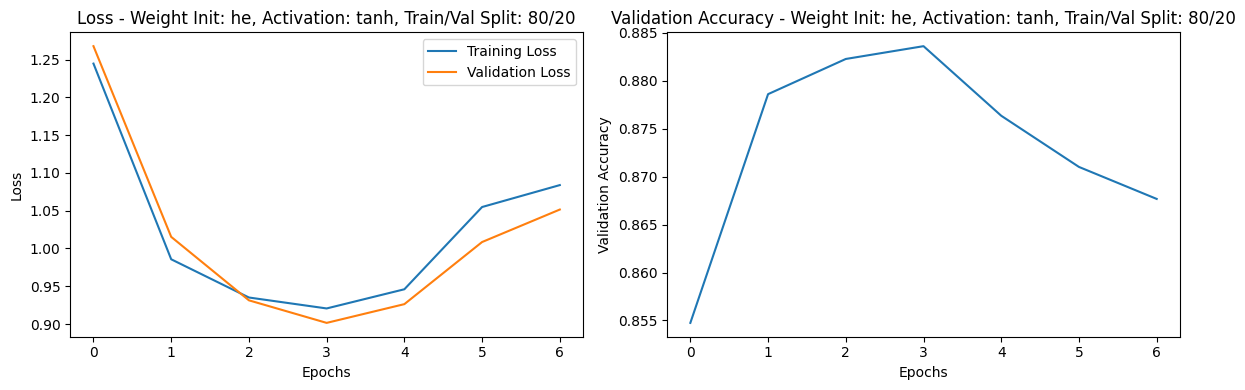

In [ ]:
# Gradient Descent Methods
gradient_methods = {
    "gradient_descent": "full_batch",
    "stochastic_gradient_descent": "stochastic",
    "mini_batch_gradient_descent": "mini_batch"
}

# Weight Initialization Methods
weight_methods = ['random', 'large', 'xavier', 'he']
activation_functions = ['relu', 'sigmoid', 'tanh']
layers = [784, 128, 64, 10]  # Input layer, 2 hidden layers, output layer
batch_size = 22
epochs = 25
learning_rate = 0.01
seed_value = 88
splits =  [(0.8, 0.2)]

for gradient_method_name, gradient_method in gradient_methods.items():
    for weight_method in weight_methods:
        for activation in activation_functions:
            for train_size, test_size in splits:

                X_train, X_val, y_train_split, y_val_split = train_test_split(
                    x_train, y_train, test_size=test_size, random_state=seed_value
                )
                X_train, X_val = X_train.T, X_val.T
                Y_train = one_hot_encode(y_train_split, 10)
                Y_val = one_hot_encode(y_val_split, 10)

                print(f"Training with Gradient Method: {gradient_method_name}, Weight Init: {weight_method}, "
                      f"Activation: {activation}, Train {train_size*100:.0f}% - Test {test_size*100:.0f}%")

                weights, biases, train_losses, val_losses, accuracies = train_network(
                    X_train, Y_train, X_val, Y_val, layers, epochs, learning_rate, batch_size, activation, lambda_reg=0,
                    method=gradient_method,early_stopping=True
                )

                plt.figure(figsize=(12, 4))

                # Plot Training and Validation Loss
                plt.subplot(1, 2, 1)
                plt.plot(train_losses, label="Training Loss")
                plt.plot(val_losses, label="Validation Loss")
                plt.xlabel("Epochs")
                plt.ylabel("Loss")
                plt.legend()
                plt.title(f"Loss - Weight Init: {weight_method}, Activation: {activation}, "
                          f"Train/Val Split: {train_size*100:.0f}/{test_size*100:.0f}")

                # Plot Validation Accuracy
                plt.subplot(1, 2, 2)
                plt.plot(accuracies)
                plt.xlabel("Epochs")
                plt.ylabel("Validation Accuracy")
                plt.title(f"Validation Accuracy - Weight Init: {weight_method}, Activation: {activation}, "
                          f"Train/Val Split: {train_size*100:.0f}/{test_size*100:.0f}")

                plt.tight_layout()
                plt.show()


**Best Possible Method**


*   It is the model with mini-batch gradient descent with highest accuracy with activation function ReLU and initialisation strategy He,considering the generalisation.



In [ ]:
layers = [784, 128, 64, 10]
batch_size = 22
epochs = 25
learning_rate = 0.01
seed_value = 88
splits =  [(0.7,0.3),(0.8, 0.2),(0.9,0.1)]


Training with Gradient Method: Mini-Batch, Weight Init: He, Activation: ReLU, Train 70% - Test 30%
Epoch 1/25 - Train Loss: 0.7811, Val Loss: 0.7755, Val Accuracy: 0.8868
Epoch 2/25 - Train Loss: 0.6806, Val Loss: 0.6858, Val Accuracy: 0.9103
Epoch 3/25 - Train Loss: 0.5726, Val Loss: 0.5739, Val Accuracy: 0.9212
Epoch 4/25 - Train Loss: 0.5370, Val Loss: 0.5560, Val Accuracy: 0.9281
Epoch 5/25 - Train Loss: 0.4625, Val Loss: 0.4739, Val Accuracy: 0.9336
Epoch 6/25 - Train Loss: 0.4151, Val Loss: 0.4373, Val Accuracy: 0.9415
Epoch 7/25 - Train Loss: 0.4139, Val Loss: 0.4337, Val Accuracy: 0.9449
Epoch 8/25 - Train Loss: 0.3675, Val Loss: 0.3966, Val Accuracy: 0.9468
Epoch 9/25 - Train Loss: 0.3354, Val Loss: 0.3637, Val Accuracy: 0.9497
Epoch 10/25 - Train Loss: 0.3226, Val Loss: 0.3592, Val Accuracy: 0.9516
Epoch 11/25 - Train Loss: 0.3031, Val Loss: 0.3433, Val Accuracy: 0.9547
Epoch 12/25 - Train Loss: 0.2995, Val Loss: 0.3463, Val Accuracy: 0.9551
Epoch 13/25 - Train Loss: 0.2758, 

<ipython-input-23-629da2df88a9>:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


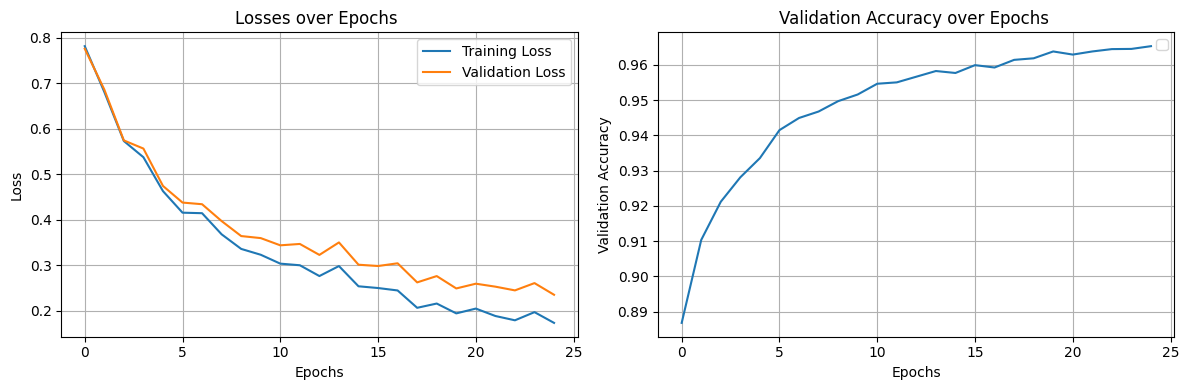

Training with Gradient Method: Mini-Batch, Weight Init: He, Activation: ReLU, Train 80% - Test 20%
Epoch 1/25 - Train Loss: 0.9176, Val Loss: 0.8798, Val Accuracy: 0.8925
Epoch 2/25 - Train Loss: 0.8363, Val Loss: 0.8264, Val Accuracy: 0.9018
Epoch 3/25 - Train Loss: 0.6245, Val Loss: 0.6188, Val Accuracy: 0.9196
Epoch 4/25 - Train Loss: 0.5858, Val Loss: 0.5907, Val Accuracy: 0.9272
Epoch 5/25 - Train Loss: 0.4665, Val Loss: 0.4885, Val Accuracy: 0.9350
Epoch 6/25 - Train Loss: 0.4473, Val Loss: 0.4559, Val Accuracy: 0.9405
Epoch 7/25 - Train Loss: 0.4273, Val Loss: 0.4592, Val Accuracy: 0.9448
Epoch 8/25 - Train Loss: 0.3806, Val Loss: 0.4133, Val Accuracy: 0.9463
Epoch 9/25 - Train Loss: 0.3396, Val Loss: 0.3681, Val Accuracy: 0.9511
Epoch 10/25 - Train Loss: 0.3178, Val Loss: 0.3582, Val Accuracy: 0.9517
Epoch 11/25 - Train Loss: 0.3085, Val Loss: 0.3441, Val Accuracy: 0.9538
Epoch 12/25 - Train Loss: 0.2768, Val Loss: 0.3056, Val Accuracy: 0.9554
Epoch 13/25 - Train Loss: 0.2812, 

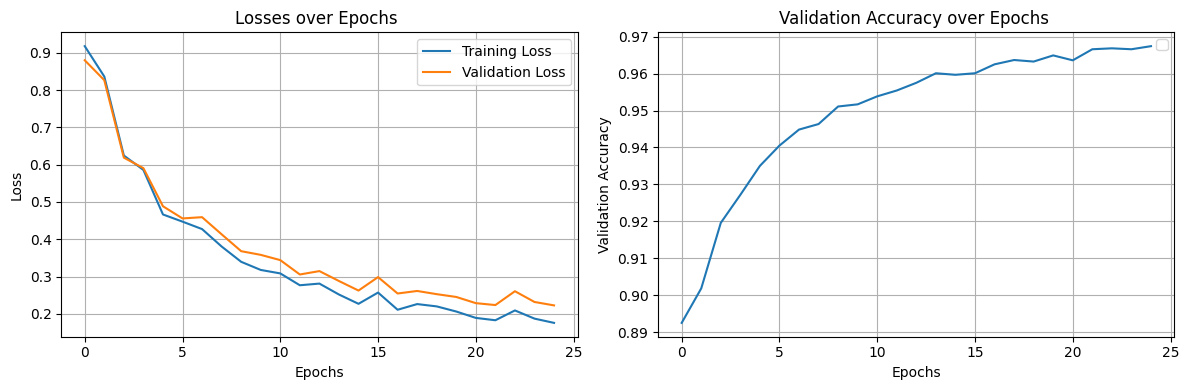

Training with Gradient Method: Mini-Batch, Weight Init: He, Activation: ReLU, Train 90% - Test 10%
Epoch 1/25 - Train Loss: 0.7864, Val Loss: 0.7872, Val Accuracy: 0.8988
Epoch 2/25 - Train Loss: 0.6479, Val Loss: 0.6506, Val Accuracy: 0.9140
Epoch 3/25 - Train Loss: 0.5534, Val Loss: 0.5451, Val Accuracy: 0.9283
Epoch 4/25 - Train Loss: 0.4833, Val Loss: 0.4851, Val Accuracy: 0.9378
Epoch 5/25 - Train Loss: 0.3877, Val Loss: 0.3927, Val Accuracy: 0.9467
Epoch 6/25 - Train Loss: 0.3610, Val Loss: 0.3647, Val Accuracy: 0.9468
Epoch 7/25 - Train Loss: 0.3609, Val Loss: 0.3708, Val Accuracy: 0.9535
Epoch 8/25 - Train Loss: 0.3327, Val Loss: 0.3438, Val Accuracy: 0.9565
Epoch 9/25 - Train Loss: 0.3028, Val Loss: 0.3125, Val Accuracy: 0.9567
Epoch 10/25 - Train Loss: 0.2805, Val Loss: 0.2919, Val Accuracy: 0.9607
Epoch 11/25 - Train Loss: 0.2670, Val Loss: 0.2860, Val Accuracy: 0.9620
Epoch 12/25 - Train Loss: 0.2487, Val Loss: 0.2640, Val Accuracy: 0.9633
Epoch 13/25 - Train Loss: 0.2399, 

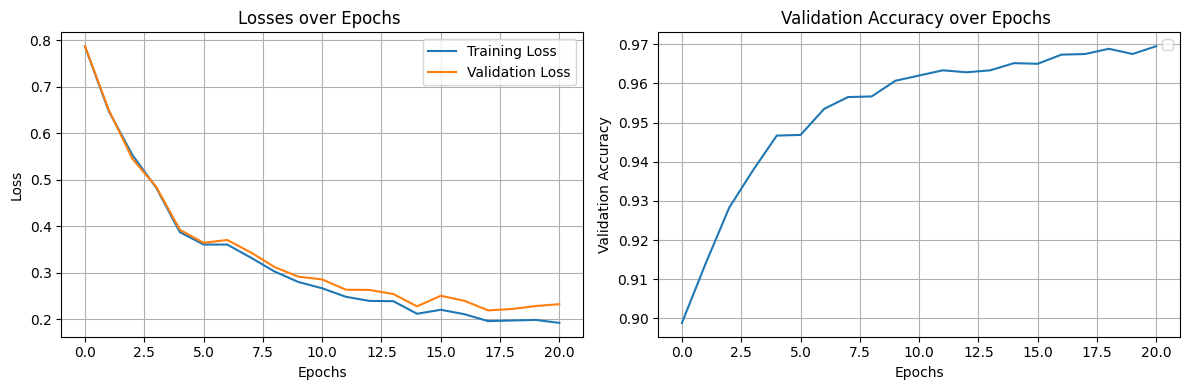

In [ ]:
for train_size, test_size in splits:
                X_train, X_val, y_train_split, y_val_split = train_test_split(
                    x_train, y_train, test_size=test_size, random_state=seed_value
                )
                X_train, X_val = X_train.T, X_val.T
                Y_train = one_hot_encode(y_train_split, 10)
                Y_val = one_hot_encode(y_val_split, 10)

                print(f"Training with Gradient Method: Mini-Batch, Weight Init: He, "
                      f"Activation: ReLU, Train {train_size*100:.0f}% - Test {test_size*100:.0f}%")

                weights, biases, train_losses, val_losses, accuracies = train_network(
                    X_train, Y_train, X_val, Y_val, layers, epochs, learning_rate, batch_size, activation="relu", lambda_reg=0,
                    method="mini_batch",early_stopping=True
                )
                plt.figure(figsize=(12, 4))

                # Plot Training and Validation Loss
                plt.subplot(1, 2, 1)
                plt.plot(train_losses, label="Training Loss")
                plt.plot(val_losses, label="Validation Loss")
                plt.xlabel("Epochs")
                plt.ylabel("Loss")
                plt.legend()
                plt.grid()
                plt.title(f"Losses over Epochs ")


                # Plot Validation Accuracy
                plt.subplot(1, 2, 2)
                plt.plot(accuracies)
                plt.xlabel("Epochs")
                plt.ylabel("Validation Accuracy")
                plt.legend()
                plt.grid()

                plt.title(f"Validation Accuracy over Epochs ")


                plt.tight_layout()
                plt.show()


**Confusion Matrix**

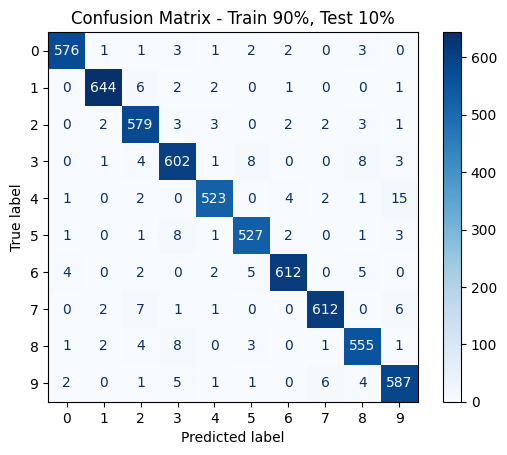

In [ ]:
activations, _ = forward_pass(X_val, weights, biases, layers, activation="relu")
y_val_pred = activations[-1]


y_val_pred_classes = np.argmax(y_val_pred, axis=0)  # Predicted classes
y_val_true_classes = np.argmax(Y_val, axis=0)      # True classes

# Confusion Matrix
cm = confusion_matrix(y_val_true_classes, y_val_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Train {train_size*100:.0f}%, Test {test_size*100:.0f}%")
plt.show()

**Parameters**

In [ ]:
def count_parameters(layers):
    total_trainable_params = 0
    total_non_trainable_params = 0  # Since there are no frozen layers.

    for i in range(len(layers) - 1):
        # Trainable Parameters
        weights = layers[i] * layers[i + 1]
        biases = layers[i + 1]
        total_trainable_params += weights + biases

    return total_trainable_params, total_non_trainable_params




In [ ]:
trainable_params, non_trainable_params = count_parameters(layers)

# Report parameters
print(f"Total Trainable Parameters: {trainable_params}")
print(f"Total Non-Trainable Parameters: {non_trainable_params}")

Total Trainable Parameters: 109386
Total Non-Trainable Parameters: 0
